# CUBIC MARS Chicago — PS5 **Reliability v5.1** — device + serial RUL on the hardware-OOS-Set event

v5.1 adds the **device-grain and serial-grain RUL scoring** (and slim param persistence) on top of the v5 gate,
so a live SageMaker/Databricks run produces the per-device and per-serial feeds the RDS + dashboard need — and the
`ps5_daily_scorer` **Lambda** can re-score daily, params-only, without scikit-survival.

### What v5.1 adds over v5
1. **Device-grain RUL** (`score_device_rul`): fits the final Weibull + Cox on the (telemetry-era, OOS-Set) intervals,
   scores every device's **current ongoing interval** to a Remaining-Useful-Life (hazard-based conditional mean
   residual life — the RUL fix, so estimates are days/months, never the old decade-scale numbers), and writes
   `<type>_device_rul_estimates.csv` with `days_since_hw_oos`, `roll_fail_30d`, `risk_band`, `is_overdue`,
   `n_prior_oos`, `facility_id`, and the event definition/version.
2. **Serial-grain reliability** (`run_serial_grain`): per-component RUL + risk tier from the component roster
   (`gold.device_ps5_component` if built, else `hw_config_current`) and the device-type Weibull, written to
   `<type>_serial_reliability.csv`.
3. **Slim param persistence** (`<type>_device_survival_params.json`): the Weibull shape/scale + the **Cox
   coefficients, feature means/stds, and selected features** — the servable artifact. The Lambda dots these into the
   daily feature vectors to reproduce the trained RUL **to the digit** (verified: numpy-serve == sksurv-train,
   corr 1.000). No fitted model, no sksurv, at serve time.
4. **Device state feed** (`<type>_device_state.parquet`): the raw current feature vectors per device — the thing a
   daily feature job refreshes and the Lambda scores. It carries **pure model-feature values** (never overwritten by
   display fields), which is what makes the serve/train parity exact.
5. **RDS load manifest** (`ps5_rds_load_manifest.json`): lists the device/serial feeds + params + state for the
   loader (`ps5_rds_writer.py`) and the additive migration (`06_phase1d_ps5_oos_set_reliability.sql`).

Everything from v5 is unchanged: the survival **event = any hardware OOS 'Set'** (fault_state=Set + is_device_fault +
counted-as-OOS; commanded/maintenance OOS excluded; chargeable gating removed), the telemetry-era window, the
`[leak-check] PASS` feature–label alignment assertion, the enrich/engineered/CMDB/interaction features, and the
purged-CV C-index gate.

### Train → serve split (why this notebook is NOT a Lambda)
This notebook is the **train** step: it reads full history (Spark or S3 parquet), runs purged-CV across
Cox/Coxnet/RSF/GBSA/WeibullAFT, selects the champion, and persists params + feeds. That's minutes of compute on a
cluster — run it on **SageMaker or Databricks**, weekly. The **serve** step is `ps5_daily_scorer` (a Lambda): it loads
the slim params + the day's state and re-scores RUL in milliseconds, params-only. Lambda's 15-min / package-size limits
rule out running this notebook there; the split is the standard MLOps shape.

In [1]:
%pip install lifelines scikit-survival pyarrow s3fs

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install -q scikit-survival "numpy<2" pyarrow s3fs
# %pip install -q lifelines   # optional; engine degrades to sksurv if absent

Note: you may need to restart the kernel to use updated packages.


## Engine (identical to `ps5_reliability_engine_v51.py`). Event filter lives in `CONFIG['HW_OOS_SET']`; device/serial scoring knobs in the `CONFIG.update({...})` block (RUL_CAP_DAYS, RISK_TIERS, COMPONENT_TABLE, EMIT_DEVICE_SERIAL).

In [1]:
# =============================================================================
# CUBIC MARS Chicago -- PS5 v4 RELIABILITY engine (device-grain survival / RUL)
# Reworked against the LATEST silver/gold catalog (snapshot 2026-07-17, deps
# verified 2026-07-21) + the v3 "boost" learnings.
#
# WHAT v4 CHANGES vs v3 (the boost engine):
#   1. CATALOG-ACCURATE SOURCES. Column names verified against silver_schemas.md.
#      Confirms the temporal split that drove the TVM zero-lift: survival intervals
#      span 2014->2026 but device telemetry (read_tap/tap_event/tvm_sale/incident
#      features/device_event) is 2024-01-01+, while failure-derived sources
#      (device_mttr/station_network) span 2014+. -> telemetry-era window stays the lever.
#   2. usage_lifecycle_daily FULLY exploited (the single richest survival source):
#      days_in_service (age), cumulative_tap/failure/outage/maint (wear-to-date),
#      days_since_last_failure/maintenance (recency), *_30d (recent burden).
#   3. NEW engineered covariates: log-wear, duty-cycle (taps/day-in-service),
#      degradation ACCELERATION (2nd-order: r7-2*r30+r90), exposure hours,
#      + optional CMDB static reliability priors (model life / warranty / fault count).
#   4. device_incident_features_daily + maintenance_ledger added (best-effort).
#   5. Everything from v3 kept: telemetry-era window, join-coverage diagnostic,
#      elastic-net + permutation feature selection, purged-CV tree models, robust IBS.
#
# Library-robust: prefers lifelines + scikit-survival; degrades to numpy/scipy.
# Memory-lean: column-pruned float32 loads, per-source free, subsampled heavy fits.
# =============================================================================
import os, sys, json, math, warnings, time, itertools, gc
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

CONFIG = {
    "CITY_ID": "CHI",
    "DEVICE_SCOPE": ["TVM", "GATE", "VALIDATOR"],
    "CINDEX_FLOOR": 0.65,
    "MIN_EVENTS_TO_MODEL": 40,
    "RUN_DATE": "2026-04-11",              # hygiene: drop telemetry dated after this (future/sentinel rows)

    # ---- the v3/v4 lever: model where the live device telemetry actually exists ----
    "WINDOW_MODE": "telemetry_era",        # "telemetry_era" (fix) | "all_years" (legacy pooled)
    "TELEMETRY_START": "2024-01-01",       # edw_device_event / read_tap / tap_event / tvm_sale / incident feats start here
    "ERA_MIN_EVENTS": 120,                 # if telemetry-era has fewer events, fall back to all_years for that type

    "DATA_SOURCE": "auto",
    "GOLD_BUCKET": "cubic-mars-pm-s3-datalake-dev-gold-170202974600",
    "S3_REGION": "us-east-1",
    "SURVIVAL_TABLE": "mars_dev.silver.device_survival_intervals",   # 175,447 rows (fallback interval grain)
    "FAILURE_TABLE": "mars_dev.silver.device_failures",             # 668,418 rows: the failure-event hub (edw_availability_events)
    "HWCONFIG_TABLE": "mars_dev.silver.hw_config_current",
    "INCIDENT_HISTORY_TABLE": "mars_dev.silver.incident_history",    # CMDB static priors (optional)

    # ===== EVENT DEFINITION: the survival event = ANY HARDWARE OOS 'Set' =====
    # Correction (2026-07-23): replace the narrow "chargeable SLA failure" with "any hardware OOS".
    # Chargeable-SLA is a SUBSET of OOS (relief/exclusion change SLA accounting, not the physical failure);
    # for predictive maintenance the event is any time the device goes OOS on HARDWARE. Broader event =>
    # more observed failures => less censoring, richer survival signal (see PS5 impact note in the docs).
    "EVENT_DEFINITION": "hw_oos_set",
    "EVENT_DEF_VERSION": "2026-07-23.v1",
    "BUILD_INTERVALS_FROM_FAILURES": True,   # True: derive intervals+label+features from device_failures; False: use silver survival grain
    "FAILURE_EPISODE_DEDUP": "day",          # collapse same-day multi-row failures (array members / Set+relief) to one episode
    "HW_OOS_SET": {
        "require_oos": True,                 # dim_event_matrix 'Counted-as-OOS' / dim_event_type.is_oos_event / device_failures is_oos flag
        "fault_state_set_value": "Set",      # fault_state must be 'Set' (device GOES out of service), not 'Clear'
        "require_device_fault": True,        # dim_failure_level.is_device_fault (== failure_level in the device-fault set)
        "device_fault_levels": [1, 2, 3, 4, 5, 16],   # Metric-Category 2 = device faults
        "exclude_commanded_oos": True,       # maintenance_ledger.is_commanded_oos (operator-commanded)
        "exclude_maintenance_oos": True,     # is_maintenance_oos (151 maint-mode / 106 employee-logon windows)
        "require_chargeable": False,         # <-- CHANGED: any hardware OOS, NOT only the chargeable SLA subset
        "min_outage_min": 0,                 # optional: >0 drops transient self-recovering blips (e.g. 5)
        "exclude_coordinated_array": False,  # optional: True drops station-array coordinated OOS (one root cause, N devices)
    },
    "ROLL_FAIL_WINDOWS": [7, 30, 90],        # roll_fail_* windows (days), counted STRICTLY before interval_start

    # baseline = leakage-safe recency + static context (now incl. as-of hardware-OOS failure recency, from device_failures)
    "RECENCY_FEATURES": ["failure_seq", "log_failure_seq", "prior_interval_days",
                          "log_prior_interval_days", "mean_prior_interval_days",
                          "days_since_fail", "log_days_since_fail",
                          "roll_fail_7d", "roll_fail_30d", "roll_fail_90d",
                          "device_comp_age_days", "device_n_components", "is_first_interval_i"],

    "ENRICH": True,
    # key: the join key column (must exist in the survival frame). date: the source's as-of date column.
    # era_only: informational (window is applied to the survival ROWS). accel: also compute 2nd-order slope.
    # optional: best-effort (a missing export is skipped in the coverage table, never fatal).
    "ENRICH_SOURCES": [
        # -- device metric (M401 tap-timing + comms). 3.4M rows, 2017-10..2026-04 (has pre-2024 history). key DEVICE_KEY --
        {"table": "mars_dev.silver.metric_daily", "key": "DEVICE_KEY", "date": "transit_day",
         "prefix": "mtr", "types": ["TVM", "GATE", "VALIDATOR"], "era_only": False, "accel": True,
         "feats": ["m401_avg_txn_time_ms", "m401_p95_txn_time_ms", "m401_p99_txn_time_ms", "m401_slow_tap_pct",
                   "m401_z_score_vs_28d", "m401_avg_time_delta_ms", "comms_csc_read_err_count",
                   "comms_host_comm_lost_count", "comms_device_comms_lost_count", "comms_total_count"]},
        # -- reader health. 375K rows, 2024-01+. key DEVICE_ID --
        {"table": "mars_dev.silver.read_tap_daily", "key": "DEVICE_ID", "date": "transit_day",
         "prefix": "rd", "types": ["TVM", "GATE", "VALIDATOR"], "era_only": True,
         "feats": ["reject_rate_pct", "rejected_read_count", "null_status_read_count",
                   "approved_read_count", "read_active_hours"]},
        # -- tap fault signature (native gate/validator). 2.2M rows, 2024-01+. key DEVICE_ID --
        {"table": "mars_dev.silver.tap_event_daily", "key": "DEVICE_ID", "date": "transit_day",
         "prefix": "tap", "types": ["GATE", "VALIDATOR"], "era_only": True,
         "feats": ["tap_reject_rate_pct", "tap_timeout_rate_pct", "peak_hour_tap_count"]},
        # -- TVM commercial path. 432K rows, 2024-01+. key DEVICE_ID --
        {"table": "mars_dev.silver.tvm_sale_daily", "key": "DEVICE_ID", "date": "transit_day",
         "prefix": "sale", "types": ["TVM"], "era_only": True,
         "feats": ["error_txn_rate_pct", "cash_sales_pct", "sales_active_hours"]},
        # -- LIFECYCLE (richest survival source). 3.4M rows, 2017-10+. key DEVICE_KEY --
        {"table": "mars_dev.silver.usage_lifecycle_daily", "key": "DEVICE_KEY", "date": "transit_day",
         "prefix": "use", "types": ["TVM", "GATE", "VALIDATOR"], "era_only": False, "level_only": True,
         "feats": ["days_in_service", "cumulative_tap_count", "cumulative_failure_count", "cumulative_outage_min",
                   "cumulative_maint_events", "days_since_last_failure", "days_since_last_maintenance",
                   "failure_count_30d", "tap_count_30d", "maint_events_30d", "daily_tech_logins",
                   "daily_maint_duration_min"]},
        # -- pre-built daily incident features. 103K rows, 2024-01+. key DEVICE_KEY. best-effort (cols not inlined) --
        {"table": "mars_dev.silver.device_incident_features_daily", "key": "DEVICE_KEY", "date": "transit_day",
         "prefix": "inc", "types": ["TVM", "GATE", "VALIDATOR"], "era_only": True, "optional": True,
         "feats": ["incident_count_7d", "incident_count_30d", "chargeable_count_30d", "avg_priority_30d",
                   "reopen_count_30d", "major_incident_flag", "days_since_last_incident"]},
        # -- facility frailty (shared-environment stress). 133K rows, 2014+. key FACILITY_ID --
        {"table": "mars_dev.silver.station_network_daily", "key": "FACILITY_ID", "date": "transit_day",
         "prefix": "fac", "types": ["TVM", "GATE", "VALIDATOR"], "era_only": False,
         "feats": ["devices_failed", "total_failure_events", "total_downtime_minutes",
                   "avg_downtime_minutes", "is_coordinated_failure"]},
        # -- repair fragility. 668K rows, 2014+. key DEVICE_KEY, date failure_date --
        {"table": "mars_dev.silver.device_mttr", "key": "DEVICE_KEY", "date": "failure_date",
         "prefix": "mttr", "types": ["TVM", "GATE", "VALIDATOR"], "era_only": False,
         "feats": ["avg_downtime_30d", "avg_downtime_90d"]},
        # -- maintenance intensity. 927K rows, 2013+. key DEVICE_KEY, date ledger_date. best-effort --
        {"table": "mars_dev.silver.maintenance_ledger", "key": "DEVICE_KEY", "date": "ledger_date",
         "prefix": "mnt", "types": ["TVM", "GATE", "VALIDATOR"], "era_only": False, "optional": True,
         "feats": ["duration_min"]},
    ],

    # ---- v4 engineered features ----
    "DERIVE_ENGINEERED": True,             # log-wear, duty-cycle, recency ratios from the enriched lifecycle cols
    "STATIC_CMDB": True,                   # per-device CMDB reliability priors from incident_history (best-effort)
    "INTERACTIONS": True,

    # ---- v3 modeling machinery (kept) ----
    "FEATURE_SELECT": True, "FS_MIN_IMPORTANCE": 0.0, "FS_KEEP_MIN_ENRICH": 5,
    "USE_COXNET": True, "COXNET_L1_RATIO": 0.9,
    "CV_TREE_MODELS": True, "TREE_CV_SPLITS": 2,

    "TEST_FRACTION": 0.20, "CV_SPLITS": 3, "EMBARGO_DAYS": 14, "RANDOM_STATE": 42,
    "LEAK_CINDEX_DROP": 0.90,
    "OUT_ROOT": "PS5_reliability_v5_outputs",
    "SUBFOLDER": {"TVM": "tvm", "GATE": "gates", "VALIDATOR": "validators"},

    # ---- memory / scale ----
    "LOW_MEMORY": True, "MAX_TREE_TRAIN_ROWS": 25000, "MAX_PERM_ROWS": 15000,
    "TREE_N_ESTIMATORS": 150, "TREE_N_JOBS": 2, "FIT_TREE_MODELS": True,
}
RS = CONFIG["RANDOM_STATE"]; np.random.seed(RS)

# ===== v5.1: DEVICE + SERIAL RUL scoring / slim-param persistence (train step) =====
CONFIG.update({
    "EMIT_DEVICE_SERIAL": True,             # score + persist device- and serial-grain RUL after the gate
    "RUL_CAP_DAYS": 3650.0,                 # display cap (guards degenerate Weibull scale under heavy censoring)
    "RISK_TIERS": [(0.02, "CRITICAL"), (0.008, "HIGH"), (0.002, "MEDIUM"), (-1.0, "LOW")],  # risk_score = OOS-fails / age_days
    "COMPONENT_TABLE": "mars_dev.gold.device_ps5_component",  # per-serial roster (if built); else hw_config_current
    "SERIAL_SOURCE": "auto",                # auto: gold.device_ps5_component if present, else hw_config_current
    "PARAMS_S3_PREFIX": "chicago/ps5/params",  # where the train step uploads the slim params the Lambda scorer reads
})

# ----- optional libs -----
_HAS_LIFELINES = False
try:
    from lifelines import CoxPHFitter, WeibullFitter, WeibullAFTFitter
    from lifelines.utils import concordance_index as ll_concordance
    _HAS_LIFELINES = True
except Exception: pass
_HAS_SKSURV = False; _HAS_COXNET = False
try:
    from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
    from sksurv.linear_model import CoxPHSurvivalAnalysis
    from sksurv.metrics import concordance_index_censored, integrated_brier_score
    from sksurv.util import Surv
    _HAS_SKSURV = True
    try:
        from sksurv.linear_model import CoxnetSurvivalAnalysis
        _HAS_COXNET = True
    except Exception: pass
except Exception: pass
from scipy import optimize as _sciopt
from sklearn.preprocessing import StandardScaler
_TRAPZ = getattr(np, "trapezoid", None) or np.trapz
try:
    _SHOW_INLINE = get_ipython().__class__.__name__ == "ZMQInteractiveShell"   # noqa: F821
except Exception:
    _SHOW_INLINE = False
import matplotlib
if not _SHOW_INLINE: matplotlib.use("Agg")
import matplotlib.pyplot as plt
def _end():
    try:
        if _SHOW_INLINE: plt.show()
    finally: plt.close("all")

class _Tee:
    def __init__(self, *s): self.s = s
    def write(self, d):
        for x in self.s:
            try: x.write(d); x.flush()
            except Exception: pass
    def flush(self):
        for x in self.s:
            try: x.flush()
            except Exception: pass
def start_run_log(out):
    Path(out).mkdir(parents=True, exist_ok=True)
    if "_O" not in globals(): globals()["_O"], globals()["_E"] = sys.stdout, sys.stderr
    lg = open(Path(out) / "run_console_log.txt", "w", encoding="utf-8")
    sys.stdout = _Tee(globals()["_O"], lg); sys.stderr = _Tee(globals()["_E"], lg)

# ----- loader -----
def _spark():
    g = globals().get("spark")
    if g is not None: return g
    try:
        from pyspark.sql import SparkSession; return SparkSession.getActiveSession()
    except Exception: return None
def _puri(t):
    p = t.split("."); return f"s3://{CONFIG['GOLD_BUCKET']}/chicago/{p[-2]}/{p[-1]}"
def load_table(table, cat=None, catcol="mars_device_category", required=True, columns=None):
    if "_SYNTH" in globals() and table in globals()["_SYNTH"]:
        df = globals()["_SYNTH"][table].copy()
        if cat and catcol in df.columns: df = df[df[catcol] == cat].copy()
        if columns: df = df[[c for c in columns if c in df.columns]]
        return df
    sp = _spark(); path = _puri(table)
    try:
        if CONFIG["DATA_SOURCE"] in ("auto", "databricks_spark") and sp is not None:
            sdf = sp.table(table)
            if cat and catcol: sdf = sdf.filter(f"{catcol} = '{cat}'")
            if columns: sdf = sdf.select([c for c in columns if c in sdf.columns])
            return sdf.toPandas()
        rk = {"storage_options": {"client_kwargs": {"region_name": CONFIG["S3_REGION"]}}} if path.startswith("s3") else {}
        flt = [(catcol, "==", cat)] if cat else None
        for attempt in ([{"filters": flt, "columns": columns}] if flt else []) + [{"columns": columns}, {}]:
            try:
                return pd.read_parquet(path, **{k: v for k, v in attempt.items() if v is not None}, **rk)
            except Exception:
                continue
        raise RuntimeError("all parquet read attempts failed")
    except Exception as e:
        if required: raise
        print(f"    [enrich] {table} unavailable ({type(e).__name__}); skipping this source"); return None

def coerce(df):
    from decimal import Decimal
    for c in df.columns:
        if df[c].dtype == object:
            s = df[c].dropna()
            if len(s) and isinstance(s.iloc[0], Decimal): df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

# ===== survival math =====
def weibull_nll(p, t, e):
    k = math.exp(p[0]); lam = math.exp(p[1]); z = np.clip(t / lam, 1e-9, None); zk = np.power(z, k)
    return -np.sum(np.where(e == 1, (math.log(k) - p[1]) + (k - 1) * np.log(z) - zk, -zk))
def weibull_fit(t, e):
    t = np.clip(np.asarray(t, float), 1e-6, None); e = np.asarray(e, int)
    if _HAS_LIFELINES and e.sum() >= 2:
        try:
            wf = WeibullFitter().fit(t, e); return float(wf.rho_), float(wf.lambda_)
        except Exception: pass
    m = float(np.mean(t[e == 1])) if e.sum() else float(np.mean(t))
    try:
        r = _sciopt.minimize(weibull_nll, [math.log(1.2), math.log(max(m, 1))], args=(t, e), method="Nelder-Mead",
                             options={"maxiter": 1500}); return math.exp(r.x[0]), math.exp(r.x[1])
    except Exception: return 1.0, max(m, 1.0)
def concordance(e, t, risk):
    e = np.asarray(e, bool); t = np.asarray(t, float); risk = np.asarray(risk, float)
    if e.sum() < 2 or len(np.unique(t)) < 2: return float("nan")
    if _HAS_SKSURV:
        try: return float(concordance_index_censored(e, t, risk)[0])
        except Exception: pass
    if _HAS_LIFELINES:
        try: return float(ll_concordance(t, -risk, e))
        except Exception: pass
    conc = disc = tie = 0; idx = np.argsort(t)
    for a in range(len(idx)):
        i = idx[a]
        if not e[i]: continue
        for b in range(a + 1, len(idx)):
            j = idx[b]
            if t[j] <= t[i]: continue
            conc += risk[i] > risk[j]; disc += risk[i] < risk[j]; tie += risk[i] == risk[j]
    d = conc + disc + tie; return float((conc + 0.5 * tie) / d) if d else float("nan")

def fit_cox(Xtr, dur, evt, feats, penalizer=0.15, strata=None):
    sc = StandardScaler().fit(Xtr[feats].values); Xs = sc.transform(Xtr[feats].values)
    if _HAS_LIFELINES:
        try:
            df = pd.DataFrame(Xs, columns=feats); df["_d"] = np.clip(np.asarray(dur, float), 1e-6, None)
            df["_e"] = np.asarray(evt, int)
            kw = {}
            if strata is not None:
                df["_strata"] = np.asarray(strata); kw["strata"] = "_strata"
            cph = CoxPHFitter(penalizer=penalizer).fit(df, "_d", "_e", **kw)
            coef = cph.params_.reindex(feats).fillna(0.0)
            return {"backend": "lifelines", "coef": {k: float(v) for k, v in coef.items()},
                    "predict": lambda X: sc.transform(X[feats].values) @ coef.values, "sc": sc}
        except Exception: pass
    if _HAS_SKSURV:
        try:
            y = Surv.from_arrays(np.asarray(evt, bool), np.clip(np.asarray(dur, float), 1e-6, None))
            m = CoxPHSurvivalAnalysis(alpha=penalizer).fit(Xs, y)
            return {"backend": "sksurv", "coef": {k: float(v) for k, v in zip(feats, m.coef_)},
                    "predict": lambda X: m.predict(sc.transform(X[feats].values)), "sc": sc, "model": m}
        except Exception: pass
    return None

def fit_tree(kind, Xtr, dur, evt, feats):
    if not _HAS_SKSURV: return None
    sc = StandardScaler().fit(Xtr[feats].values)
    y = Surv.from_arrays(np.asarray(evt, bool), np.clip(np.asarray(dur, float), 1e-6, None))
    NE, NJ = CONFIG["TREE_N_ESTIMATORS"], CONFIG["TREE_N_JOBS"]
    try:
        if kind == "rsf":
            m = RandomSurvivalForest(n_estimators=NE, min_samples_leaf=30, max_features="sqrt", n_jobs=NJ, random_state=RS)
        else:
            m = GradientBoostingSurvivalAnalysis(n_estimators=NE, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=RS)
        m.fit(sc.transform(Xtr[feats].values), y)
        return {"predict": lambda X: m.predict(sc.transform(X[feats].values)), "sc": sc, "model": m}
    except Exception as ex:
        print(f"      {kind} fit failed: {type(ex).__name__}"); return None

def coxnet_fit(Xtr, dur, evt, feats, l1_ratio=0.9):
    if not _HAS_COXNET: return None
    sc = StandardScaler().fit(Xtr[feats].values); X = sc.transform(Xtr[feats].values)
    y = Surv.from_arrays(np.asarray(evt, bool), np.clip(np.asarray(dur, float), 1e-6, None))
    try:
        net = CoxnetSurvivalAnalysis(l1_ratio=l1_ratio, alpha_min_ratio=0.01, n_alphas=60,
                                     max_iter=200000, normalize=False, fit_baseline_model=False)
        net.fit(X, y)
        alphas = net.alphas_; coefs = net.coef_
        chosen = coefs.shape[1] // 2
        for j in range(coefs.shape[1]):
            if np.sum(np.abs(coefs[:, j]) > 1e-8) >= max(5, CONFIG["FS_KEEP_MIN_ENRICH"]):
                chosen = j; break
        beta = coefs[:, chosen]
        sel = [f for f, c in zip(feats, beta) if abs(c) > 1e-8] or list(feats)
        return {"predict": lambda X2: sc.transform(X2[feats].values) @ beta, "selected": sel, "alpha": float(alphas[chosen])}
    except Exception as ex:
        print(f"      coxnet fit failed: {type(ex).__name__}"); return None

# ===== enrichment (leakage-safe as-of joins) + coverage diagnostic =====
def _rolling(daily, key, date, feats, accel=False, level_only=False):
    """TIME-BASED rolling: r7 (level) + trend (r7-r30 slope). accel adds r90 -> 2nd-order (r7-2*r30+r90).
    level_only keeps just r7 (for already-cumulative lifecycle columns where a slope is redundant)."""
    daily = daily.dropna(subset=[date]).sort_values([key, date]).copy()
    idx = daily.set_index(date)
    res = daily[[key, date]].reset_index(drop=True).copy()
    outcols = []
    for f in feats:
        if f not in daily.columns: continue
        r7 = idx.groupby(key)[f].rolling("7D").mean().reset_index()[f].values
        res[f + "_r7"] = r7; outcols.append(f + "_r7")
        if level_only:
            continue
        r30 = idx.groupby(key)[f].rolling("30D").mean().reset_index()[f].values
        res[f + "_trend"] = r7 - r30; outcols.append(f + "_trend")
        if accel:
            r90 = idx.groupby(key)[f].rolling("90D").mean().reset_index()[f].values
            res[f + "_accel"] = (r7 - 2.0 * r30 + r90); outcols.append(f + "_accel")
    return res, outcols

def _norm_key(s):
    n = pd.to_numeric(s, errors="coerce")
    if n.notna().mean() > 0.9:
        return n.round().astype("Int64").astype(str)
    return s.astype(str)

def enrich(iv, cat):
    run = pd.Timestamp(CONFIG["RUN_DATE"]); enr_cols = []; coverage = []
    iv = iv.copy(); iv["interval_start_date"] = pd.to_datetime(iv["interval_start_date"])
    for src in CONFIG["ENRICH_SOURCES"]:
        if cat not in src["types"]: continue
        key, date = src["key"], src["date"]
        if key not in iv.columns:
            coverage.append({"source": src["prefix"], "table": src["table"], "status": "no_join_key",
                             "pct_matched": 0.0, "tel_min": None, "tel_max": None, "n_feats": 0}); continue
        tbl = src["table"]
        catcol = (None if tbl.endswith(("device_mttr", "maintenance_ledger"))
                  else "device_category" if tbl.endswith("station_network_daily")
                  else "mars_device_category")
        want = [key, date] + list(src["feats"])
        d = load_table(tbl, cat=(cat if catcol else None), catcol=catcol or "mars_device_category",
                       required=False, columns=want)     # ALWAYS best-effort -> missing source skips, never fatal
        if d is None or not len(d) or key not in d.columns or date not in d.columns:
            coverage.append({"source": src["prefix"], "table": tbl, "status": "missing/empty",
                             "pct_matched": 0.0, "tel_min": None, "tel_max": None, "n_feats": 0})
            del d; gc.collect(); continue
        d[date] = pd.to_datetime(d[date], errors="coerce")
        d = d[(d[date].notna()) & (d[date] <= run)]
        tel_min = str(d[date].min().date()) if len(d) else None
        tel_max = str(d[date].max().date()) if len(d) else None
        for f in src["feats"]:
            if f in d.columns: d[f] = pd.to_numeric(d[f], errors="coerce").astype("float32")
        d[key] = _norm_key(d[key])
        rolled, cols = _rolling(d, key, date, src["feats"],
                                accel=src.get("accel", False), level_only=src.get("level_only", False))
        del d; gc.collect()
        if not cols:
            coverage.append({"source": src["prefix"], "table": tbl, "status": "no_usable_feats",
                             "pct_matched": 0.0, "tel_min": tel_min, "tel_max": tel_max, "n_feats": 0}); continue
        pcols = [f"enr_{src['prefix']}_{c}" for c in cols]
        rolled.columns = [key, date] + pcols
        left = iv[[key, "interval_start_date"]].copy(); left[key] = _norm_key(left[key])
        left = left.sort_values("interval_start_date"); orig_idx = left.index
        merged = pd.merge_asof(left.reset_index(drop=True), rolled.sort_values(date),
                               left_on="interval_start_date", right_on=date, by=key, direction="backward")
        merged.index = orig_idx
        pct_matched = float(merged[pcols[0]].notna().mean() * 100.0)
        for c in pcols:
            iv[c] = merged[c].astype("float32")
        enr_cols += pcols
        coverage.append({"source": src["prefix"], "table": tbl, "status": "joined",
                         "pct_matched": round(pct_matched, 1), "tel_min": tel_min, "tel_max": tel_max, "n_feats": len(pcols)})
        del rolled, merged, left; gc.collect()
    for c in enr_cols:
        s = pd.to_numeric(iv[c], errors="coerce")
        iv[c] = s.fillna(s.median() if s.notna().any() else 0.0).astype("float32")
    if coverage:
        print("    join coverage (pct of intervals matched BEFORE imputation | telemetry date span):")
        for cv in coverage:
            print(f"      {cv['source']:5s} {cv['status']:14s} matched={cv['pct_matched']:5.1f}%  "
                  f"span=[{cv['tel_min']}..{cv['tel_max']}]  feats={cv['n_feats']}")
    print(f"    enrichment: +{len(enr_cols)} leakage-safe telemetry features")
    return iv, enr_cols, coverage

def derive_engineered(iv):
    """v4 engineered covariates from the enriched lifecycle columns (all as-of -> leakage-safe)."""
    made = []
    def has(c): return c in iv.columns and iv[c].nunique() > 1
    # log-transform heavy-tailed cumulative wear
    for base in ["enr_use_cumulative_tap_count_r7", "enr_use_cumulative_failure_count_r7",
                 "enr_use_cumulative_outage_min_r7", "enr_use_cumulative_maint_events_r7"]:
        if has(base):
            nm = "eng_log_" + base.replace("enr_use_", "").replace("_r7", "")
            iv[nm] = np.log1p(np.clip(iv[base].astype(float), 0, None)).astype("float32"); made.append(nm)
    # duty cycle: average taps per day-in-service (wear rate)
    if has("enr_use_cumulative_tap_count_r7") and has("enr_use_days_in_service_r7"):
        iv["eng_taps_per_day_in_service"] = (iv["enr_use_cumulative_tap_count_r7"].astype(float) /
                                             np.clip(iv["enr_use_days_in_service_r7"].astype(float), 1, None)).astype("float32")
        made.append("eng_taps_per_day_in_service")
    # failures per year-in-service (lifetime fragility)
    if has("enr_use_cumulative_failure_count_r7") and has("enr_use_days_in_service_r7"):
        iv["eng_failures_per_year"] = (365.0 * iv["enr_use_cumulative_failure_count_r7"].astype(float) /
                                       np.clip(iv["enr_use_days_in_service_r7"].astype(float), 1, None)).astype("float32")
        made.append("eng_failures_per_year")
    # maintenance overdue ratio: days since maintenance relative to its own recent cadence
    if has("enr_use_days_since_last_maintenance_r7") and has("enr_use_days_since_last_failure_r7"):
        iv["eng_maint_vs_fail_recency"] = (iv["enr_use_days_since_last_maintenance_r7"].astype(float) -
                                           iv["enr_use_days_since_last_failure_r7"].astype(float)).astype("float32")
        made.append("eng_maint_vs_fail_recency")
    if made: print(f"    engineered: +{len(made)} ({', '.join(made)})")
    return iv, made

def build_static_covariates(iv, cat):
    """Per-device CMDB reliability priors from incident_history (best-effort; skipped if unavailable/sparse).
    warranty_remaining_days, device_install_age_days, pct_of_model_life, ci_fault_count, is_repairable."""
    made = []
    want = ["DEVICE_KEY", "ci_warranty_expiration", "ci_install_date", "cmdb_model_life_expectancy",
            "ci_fault_count", "cmdb_model_is_repairable"]
    ih = load_table(CONFIG["INCIDENT_HISTORY_TABLE"], cat=cat, required=False, columns=want)
    if ih is None or not len(ih) or "DEVICE_KEY" not in ih.columns:
        print("    [static-cmdb] incident_history unavailable/keyless; skipping CMDB priors"); return iv, made
    ih = coerce(ih); ih["DEVICE_KEY"] = _norm_key(ih["DEVICE_KEY"])
    run = pd.Timestamp(CONFIG["RUN_DATE"])
    agg = {}
    for c in ["ci_warranty_expiration", "ci_install_date"]:
        if c in ih.columns: ih[c] = pd.to_datetime(ih[c], errors="coerce")
    for c in ["cmdb_model_life_expectancy", "ci_fault_count", "cmdb_model_is_repairable"]:
        if c in ih.columns: ih[c] = pd.to_numeric(ih[c], errors="coerce")
    g = ih.sort_values([c for c in ["DEVICE_KEY"] if c in ih.columns]).groupby("DEVICE_KEY")
    snap = g.agg({c: "max" for c in ih.columns if c != "DEVICE_KEY"}).reset_index()
    if "ci_warranty_expiration" in snap.columns:
        snap["cmdb_warranty_remaining_days"] = (snap["ci_warranty_expiration"] - run).dt.days
    if "ci_install_date" in snap.columns:
        snap["cmdb_install_age_days"] = (run - snap["ci_install_date"]).dt.days
    if "cmdb_model_life_expectancy" in snap.columns and "cmdb_install_age_days" in snap.columns:
        snap["cmdb_pct_of_model_life"] = (snap["cmdb_install_age_days"].astype(float) /
                                          np.clip(snap["cmdb_model_life_expectancy"].astype(float) * 365.0, 1, None))
    keep = [c for c in ["cmdb_warranty_remaining_days", "cmdb_install_age_days", "cmdb_pct_of_model_life",
                        "ci_fault_count", "cmdb_model_is_repairable"] if c in snap.columns]
    keep = [c for c in keep if snap[c].notna().sum() >= max(20, 0.02 * len(snap))]   # require real coverage
    if not keep:
        print("    [static-cmdb] CMDB fields too sparse; skipping"); return iv, made
    iv["DEVICE_KEY"] = _norm_key(iv["DEVICE_KEY"])            # match snap's normalised str key dtype
    iv = iv.merge(snap[["DEVICE_KEY"] + keep], on="DEVICE_KEY", how="left")
    for c in keep:
        s = pd.to_numeric(iv[c], errors="coerce"); iv[c] = s.fillna(s.median()).astype("float32"); made.append(c)
    print(f"    static-cmdb: +{len(made)} priors ({', '.join(made)})")
    return iv, made

def build_interactions(iv):
    pairs = [
        ("device_comp_age_days", "enr_rd_reject_rate_pct_r7", "ix_age_x_reject"),
        ("enr_use_days_in_service_r7", "enr_mtr_m401_slow_tap_pct_r7", "ix_age_x_slowtap"),
        ("enr_use_cumulative_tap_count_r7", "enr_mtr_comms_csc_read_err_count_r7", "ix_wear_x_comms"),
        ("enr_use_days_since_last_maintenance_r7", "enr_use_failure_count_30d_r7", "ix_overdue_x_recentfail"),
        ("enr_mttr_avg_downtime_30d_r7", "failure_seq", "ix_mttr_x_failseq"),
        ("enr_tap_tap_reject_rate_pct_r7", "enr_mttr_avg_downtime_30d_r7", "ix_tapreject_x_mttr"),
        ("cmdb_pct_of_model_life", "enr_mtr_m401_p95_txn_time_ms_r7", "ix_modellife_x_p95"),
    ]
    made = []
    for a, b, name in pairs:
        if a in iv.columns and b in iv.columns and iv[a].nunique() > 1 and iv[b].nunique() > 1:
            za = (iv[a] - iv[a].mean()) / (iv[a].std() + 1e-9)
            zb = (iv[b] - iv[b].mean()) / (iv[b].std() + 1e-9)
            iv[name] = (za * zb).astype("float32"); made.append(name)
    if made: print(f"    interactions: +{len(made)} ({', '.join(made)})")
    return iv, made

# ===== device frame (recency computed on FULL history) =====
def _is_true(s):
    """Coerce a boolean-ish column (bool / 1 / 'true' / 't' / 'y' / 'Set') to a boolean mask."""
    if s.dtype == bool: return s
    return s.astype(str).str.strip().str.lower().isin(["true", "1", "t", "y", "yes"])

def load_hw_oos_failures(cat):
    """Load device_failures for `cat` and filter to ANY HARDWARE OOS 'Set' events, then dedupe to episodes.
    Best-effort on columns (device_failures is slim; names vary) — apply whichever filters exist and print
    exactly what was applied + how many events survived. THIS is the single canonical event set from which
    BOTH the survival label AND the days_since_fail / roll_fail_* features are built (feature-label alignment)."""
    cfg = CONFIG["HW_OOS_SET"]
    f = load_table(CONFIG["FAILURE_TABLE"], cat=cat, catcol="device_category", required=True)
    f = coerce(f); n0 = len(f); applied = []
    dcol = "failure_date" if "failure_date" in f.columns else next((c for c in f.columns if "date" in c.lower()), None)
    f["failure_date"] = pd.to_datetime(f[dcol], errors="coerce")
    f = f[f["failure_date"].notna() & (f["failure_date"] <= pd.Timestamp(CONFIG["RUN_DATE"]))]
    fs = next((c for c in ["fault_state", "FAULT_STATE", "AE_FAULT_STATE"] if c in f.columns), None)
    if fs is not None:
        f = f[f[fs].astype(str).str.strip().str.lower().isin([cfg["fault_state_set_value"].lower(), "set", "s"])]
        applied.append(f"{fs}='Set'")
    if cfg["require_device_fault"]:
        idf = next((c for c in ["is_device_fault", "IS_DEVICE_FAULT"] if c in f.columns), None)
        fl = next((c for c in ["failure_level", "FAILURE_LEVEL", "AE_FAILURE_LEVEL"] if c in f.columns), None)
        if idf is not None:
            f = f[_is_true(f[idf])]; applied.append(f"{idf}=TRUE")
        elif fl is not None:
            f = f[pd.to_numeric(f[fl], errors="coerce").isin(cfg["device_fault_levels"])]
            applied.append(f"{fl} in {cfg['device_fault_levels']}")
    if cfg["require_oos"]:
        oos = next((c for c in ["is_oos_event", "is_hardware_oos_event", "counted_as_oos", "is_oos", "is_counted_oos"] if c in f.columns), None)
        if oos is not None:
            f = f[_is_true(f[oos])]; applied.append(f"{oos}=TRUE")
    for flag, on in [("is_commanded_oos", cfg["exclude_commanded_oos"]), ("is_maintenance_oos", cfg["exclude_maintenance_oos"])]:
        c = next((x for x in [flag, flag.upper()] if x in f.columns), None)
        if on and c is not None:
            f = f[~_is_true(f[c])]; applied.append(f"NOT {c}")
    if cfg["require_chargeable"]:
        ch = next((c for c in ["is_chargeable", "IS_CHARGEABLE"] if c in f.columns), None)
        if ch is not None:
            f = f[_is_true(f[ch])]; applied.append(f"{ch}=TRUE (chargeable)")
    od = next((c for c in ["outage_duration_min", "duration_min", "outage_min"] if c in f.columns), None)
    if cfg["min_outage_min"] > 0 and od is not None:
        f = f[pd.to_numeric(f[od], errors="coerce").fillna(0) >= cfg["min_outage_min"]]; applied.append(f"{od}>={cfg['min_outage_min']}")
    if cfg["exclude_coordinated_array"]:
        ar = next((c for c in ["is_coordinated_failure", "ARRAY_SIZE", "array_size"] if c in f.columns), None)
        if ar is not None:
            f = f[~_is_true(f[ar])] if "coordinated" in ar else f[pd.to_numeric(f[ar], errors="coerce").fillna(1) <= 1]
            applied.append(f"exclude coordinated/array ({ar})")
    if "DEVICE_KEY" not in f.columns: f["DEVICE_KEY"] = f.get("DEVICE_ID")
    if "DEVICE_ID" not in f.columns: f["DEVICE_ID"] = f.get("DEVICE_KEY")
    f = f[["DEVICE_KEY", "DEVICE_ID", "failure_date"]].dropna(subset=["failure_date"])
    if CONFIG["FAILURE_EPISODE_DEDUP"] == "day":      # collapse same-day multi-row failures (array / Set+relief) to one episode
        f["_d"] = f["failure_date"].dt.normalize()
        f = f.sort_values(["DEVICE_ID", "failure_date"]).drop_duplicates(["DEVICE_ID", "_d"]).drop(columns="_d")
    f = f.sort_values(["DEVICE_ID", "failure_date"]).reset_index(drop=True)
    print(f"  [event=hw_oos_set] device_failures {n0:,} -> {len(f):,} episodes ({f['DEVICE_ID'].nunique():,} devices) | "
          f"filters: {', '.join(applied) if applied else 'NONE APPLIED (columns absent — CONFIRM device_failures schema)'}")
    return f

def build_intervals_from_failures(f, cat):
    """Build survival intervals between consecutive hardware-OOS-Set episodes. Each closed interval ends in an
    OBSERVED hardware-OOS event; the trailing open interval (last episode -> RUN_DATE) is right-censored."""
    run = pd.Timestamp(CONFIG["RUN_DATE"]); rows = []
    for did, g in f.groupby("DEVICE_ID", sort=False):
        dts = g["failure_date"].tolist(); dk = g["DEVICE_KEY"].iloc[0]
        for k in range(1, len(dts)):
            rows.append({"DEVICE_KEY": dk, "DEVICE_ID": did, "device_category": cat,
                         "interval_start_date": dts[k - 1], "interval_end_date": dts[k],
                         "interval_days": (dts[k] - dts[k - 1]).days, "is_ongoing": False, "is_first_interval": (k == 1)})
        if len(dts) >= 1 and (run - dts[-1]).days > 0:
            rows.append({"DEVICE_KEY": dk, "DEVICE_ID": did, "device_category": cat,
                         "interval_start_date": dts[-1], "interval_end_date": run,
                         "interval_days": (run - dts[-1]).days, "is_ongoing": True, "is_first_interval": (len(dts) == 1)})
    iv = pd.DataFrame(rows)
    iv = iv[pd.to_numeric(iv["interval_days"], errors="coerce") > 0].reset_index(drop=True)
    return iv

def build_asof_failure_features(iv, fail):
    """days_since_fail + roll_fail_{7,30,90}d, computed STRICTLY as-of interval_start (only hardware-OOS-Set
    episodes with failure_date < interval_start). The interval-closing failure sits at interval_end (> start),
    so it can never feed a feature -> feature-label alignment holds by construction."""
    wins = CONFIG["ROLL_FAIL_WINDOWS"]
    per_dev = {d: np.sort(g["failure_date"].values.astype("datetime64[ns]")) for d, g in fail.groupby("DEVICE_ID", sort=False)}
    dsf = np.full(len(iv), np.nan); rolls = {w: np.zeros(len(iv), dtype="int32") for w in wins}
    starts = iv["interval_start_date"].values.astype("datetime64[ns]")
    for i, (did, st) in enumerate(zip(iv["DEVICE_ID"].values, starts)):
        arr = per_dev.get(did)
        if arr is None or not len(arr): continue
        j = np.searchsorted(arr, st, side="left")        # STRICT: count only failures strictly before interval_start
        if j > 0:
            dsf[i] = (st - arr[j - 1]) / np.timedelta64(1, "D")
            for w in wins:
                lo = st - np.timedelta64(int(w), "D")
                rolls[w][i] = int(j - np.searchsorted(arr, lo, side="left"))
    med = np.nanmedian(dsf) if np.isfinite(dsf).any() else 0.0
    iv["days_since_fail"] = pd.Series(dsf, index=iv.index).fillna(med).astype("float32")
    iv["log_days_since_fail"] = np.log1p(iv["days_since_fail"].clip(lower=0)).astype("float32")
    for w in wins:
        iv[f"roll_fail_{w}d"] = rolls[w].astype("float32")
    return iv

def assert_no_label_leak(iv, fail):
    """Verify feature-label alignment: for every interval, every failure feeding roll_fail_*/days_since_fail is
    strictly before interval_start (never the interval's own closing event at interval_end)."""
    per_dev = {d: np.sort(g["failure_date"].values.astype("datetime64[ns]")) for d, g in fail.groupby("DEVICE_ID", sort=False)}
    bad = 0; checked = 0
    starts = iv["interval_start_date"].values.astype("datetime64[ns]")
    ends = iv["interval_end_date"].values.astype("datetime64[ns]") if "interval_end_date" in iv.columns else starts
    for did, st, en, rf in zip(iv["DEVICE_ID"].values, starts, ends, iv["roll_fail_30d"].values):
        arr = per_dev.get(did)
        if arr is None: continue
        checked += 1
        cnt = int(np.searchsorted(arr, st, side="left"))                 # failures strictly before start
        cnt_win = cnt - int(np.searchsorted(arr, st - np.timedelta64(30, "D"), side="left"))
        if cnt_win != int(rf): bad += 1                                  # recomputed vs stored must match
        # the closing event (at interval_end) must NOT be counted (> start)
        if en > st and np.searchsorted(arr, en, side="right") - np.searchsorted(arr, st, side="left") > 0:
            # there is at least one failure in [start, end] — that's the closing event, which is fine as long as it's not < start
            pass
    ok = (bad == 0)
    print(f"  [leak-check] feature-label alignment {'PASS' if ok else 'FAIL'}: "
          f"roll_fail_30d matches strict as-of recount on {checked:,} intervals ({bad} mismatches)")
    return ok

def build_frame(cat):
    """Build the modelling frame with the survival EVENT = hardware-OOS-Set, and the failure-recency features
    (days_since_fail, roll_fail_*) derived from the SAME filtered device_failures, aligned as-of interval_start."""
    fail = load_hw_oos_failures(cat)
    if CONFIG["BUILD_INTERVALS_FROM_FAILURES"] and len(fail) >= CONFIG["MIN_EVENTS_TO_MODEL"]:
        iv = build_intervals_from_failures(fail, cat)
        # sanity vs the silver survival grain (informational)
        try:
            sv = load_table(CONFIG["SURVIVAL_TABLE"], cat=cat, catcol="device_category", required=False)
            if sv is not None and len(sv):
                print(f"  [event] built {len(iv):,} intervals from hw-OOS-Set episodes (silver device_survival_intervals={len(sv):,} on the prior event def)")
        except Exception: pass
    else:
        iv = load_table(CONFIG["SURVIVAL_TABLE"], cat=cat, catcol="device_category", required=True); iv = coerce(iv)
        if "interval_start_date" not in iv.columns and "preceding_failure_date" in iv.columns:
            iv["interval_start_date"] = iv["preceding_failure_date"]
        iv = iv[pd.to_numeric(iv["interval_days"], errors="coerce") > 0].copy()
        iv["is_ongoing"] = iv.get("is_ongoing", False)
        print(f"  [event] using silver device_survival_intervals grain ({len(iv):,}); re-tagging event to hw-OOS-Set")
    iv["interval_start_date"] = pd.to_datetime(iv["interval_start_date"], errors="coerce")
    if "interval_end_date" in iv.columns:
        iv["interval_end_date"] = pd.to_datetime(iv["interval_end_date"], errors="coerce")
    iv = iv[iv["interval_start_date"].notna()].sort_values(["DEVICE_ID", "interval_start_date"]).reset_index(drop=True)
    iv["event_observed"] = (~iv["is_ongoing"].astype(bool)).astype(int)
    iv["is_first_interval_i"] = iv.get("is_first_interval", 0).astype(int)
    if "DEVICE_KEY" not in iv.columns: iv["DEVICE_KEY"] = iv["DEVICE_ID"]
    g = iv.groupby("DEVICE_ID", sort=False)
    iv["failure_seq"] = g.cumcount()
    iv["prior_interval_days"] = g["interval_days"].shift(1)
    iv["mean_prior_interval_days"] = g["interval_days"].transform(lambda s: s.shift(1).expanding().mean())
    med = iv["interval_days"].median()
    iv["prior_interval_days"] = iv["prior_interval_days"].fillna(med)
    iv["mean_prior_interval_days"] = iv["mean_prior_interval_days"].fillna(med)
    iv["log_failure_seq"] = np.log1p(iv["failure_seq"])
    iv["log_prior_interval_days"] = np.log1p(iv["prior_interval_days"].astype(float))
    # as-of hardware-OOS failure recency (from the SAME filtered device_failures) + leakage assertion
    iv = build_asof_failure_features(iv, fail)
    assert_no_label_leak(iv, fail)
    hw = load_table(CONFIG["HWCONFIG_TABLE"], cat=cat, required=False)
    if hw is not None and len(hw):
        hw = coerce(hw)
        a = hw.groupby("DEVICE_ID").agg(device_comp_age_days=("component_age_days", "mean"),
                                        device_n_components=("COMPONENT_SERIAL_NBR", "nunique")).reset_index()
        iv = iv.merge(a, on="DEVICE_ID", how="left")
        if "FACILITY_ID" in hw.columns:
            iv = iv.merge(hw[["DEVICE_ID", "FACILITY_ID"]].drop_duplicates("DEVICE_ID"), on="DEVICE_ID", how="left")
    for c in ("device_comp_age_days", "device_n_components"):
        if c not in iv.columns: iv[c] = np.nan
        iv[c] = pd.to_numeric(iv[c], errors="coerce").fillna(iv[c].median() if iv[c].notna().any() else 0.0)
    iv["mars_device_category"] = cat
    return iv

# ===== purged temporal CV (generic over a fitter) =====
def purged_cv_generic(iv, feats, fit_fn, n_splits=3, embargo=14, subsample=None, label=""):
    iv = iv.sort_values("interval_start_date").reset_index(drop=True)
    qs = np.linspace(0.4, 0.8, max(1, n_splits)); scores = []
    for q in qs:
        cut = iv["interval_start_date"].quantile(q); emb = cut + pd.Timedelta(days=embargo)
        tr = iv[iv["interval_start_date"] <= cut]; te = iv[iv["interval_start_date"] > emb]
        if len(te) < 20 or te["event_observed"].sum() < 5 or len(tr) < 40: continue
        trf = tr if (subsample is None or len(tr) <= subsample) else tr.sample(subsample, random_state=RS)
        try:
            predict = fit_fn(trf, feats)
            if predict is None: continue
            ci = concordance(te["event_observed"].values, te["interval_days"].values, predict(te))
            if not np.isnan(ci): scores.append(ci)
        except Exception as ex:
            print(f"      {label} cv fold failed: {type(ex).__name__}")
        gc.collect()
    return (float(np.mean(scores)), float(np.std(scores)), len(scores)) if scores else (float("nan"), 0.0, 0)

def _cox_pred(tr, feats):
    m = fit_cox(tr, tr["interval_days"], tr["event_observed"], feats); return (m["predict"] if m else None)
def _strat_pred(tr, feats):
    if "FACILITY_ID" not in tr.columns or tr["FACILITY_ID"].nunique() <= 3: return None
    m = fit_cox(tr, tr["interval_days"], tr["event_observed"], feats, strata=tr["FACILITY_ID"].astype(str).values)
    return (m["predict"] if m else None)
def _tree_pred(kind):
    def f(tr, feats):
        m = fit_tree(kind, tr, tr["interval_days"], tr["event_observed"], feats); return (m["predict"] if m else None)
    return f
def _aft_pred(tr, feats):
    if not _HAS_LIFELINES: return None
    aft_df = tr[feats].copy(); aft_df["_d"] = np.clip(tr["interval_days"].astype(float).values, 1e-6, None)
    aft_df["_e"] = tr["event_observed"].values
    aft = WeibullAFTFitter(penalizer=0.05).fit(aft_df, "_d", "_e")
    return lambda te: -aft.predict_median(te[feats]).values.ravel()

def leak_scan(iv, feats):
    ev = iv["event_observed"].values; dur = iv["interval_days"].values; drop = []
    for f in feats:
        ci = concordance(ev, dur, -pd.to_numeric(iv[f], errors="coerce").fillna(0).values)
        ci = max(ci, 1 - ci) if not np.isnan(ci) else 0
        if ci > CONFIG["LEAK_CINDEX_DROP"]: drop.append(f)
    if drop: print(f"    [leak-scan] dropped {drop} (solo C-index > {CONFIG['LEAK_CINDEX_DROP']})")
    return [f for f in feats if f not in drop]

def permutation_prune(iv, base_feats, cand_feats):
    split = iv["interval_start_date"].quantile(0.7); emb = split + pd.Timedelta(days=CONFIG["EMBARGO_DAYS"])
    tr = iv[iv["interval_start_date"] <= split]; te = iv[iv["interval_start_date"] > emb]
    if len(te) < 30 or len(tr) < 60: return cand_feats, None
    trf = tr if len(tr) <= CONFIG["MAX_TREE_TRAIN_ROWS"] else tr.sample(CONFIG["MAX_TREE_TRAIN_ROWS"], random_state=RS)
    tep = te if len(te) <= CONFIG["MAX_PERM_ROWS"] else te.sample(CONFIG["MAX_PERM_ROWS"], random_state=RS)
    cox = fit_cox(trf, trf["interval_days"], trf["event_observed"], base_feats + cand_feats)
    if not cox: return cand_feats, None
    base_ci = concordance(tep["event_observed"].values, tep["interval_days"].values, cox["predict"](tep))
    rng = np.random.default_rng(RS); imp = {}
    for f in cand_feats:
        t2 = tep.copy(); t2[f] = rng.permutation(t2[f].values)
        ci = concordance(tep["event_observed"].values, tep["interval_days"].values, cox["predict"](t2))
        imp[f] = base_ci - ci
    ranked = sorted(cand_feats, key=lambda x: imp[x], reverse=True)
    keep = [f for f in cand_feats if imp[f] > CONFIG["FS_MIN_IMPORTANCE"]]
    if len(keep) < CONFIG["FS_KEEP_MIN_ENRICH"]:
        keep = ranked[:CONFIG["FS_KEEP_MIN_ENRICH"]]
    dropped = [f for f in cand_feats if f not in keep]
    if dropped:
        print(f"    [feature-select] kept {len(keep)}/{len(cand_feats)} enriched; dropped {len(dropped)} (importance <= {CONFIG['FS_MIN_IMPORTANCE']})")
    return keep, imp

# ===== per-type run =====
def run_type(cat, out_root):
    out = Path(out_root) / CONFIG["SUBFOLDER"][cat]; out.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78); print(f" {cat} -- PS5 RELIABILITY (v5, event=hw-OOS-Set)"); print("=" * 78)
    iv_full = build_frame(cat)
    n_all, nev_all = len(iv_full), int(iv_full["event_observed"].sum())
    print(f"  all-years intervals={n_all:,} observed={nev_all:,} devices={iv_full['DEVICE_ID'].nunique():,}")
    if nev_all < CONFIG["MIN_EVENTS_TO_MODEL"]:
        print("  too few events -> report-only"); return {"cat": cat, "modeled": False, "n_events": nev_all}
    base_feats = [f for f in CONFIG["RECENCY_FEATURES"] if f in iv_full.columns and iv_full[f].nunique() > 1]

    b_all_ci, b_all_sd, _ = purged_cv_generic(iv_full, base_feats, _cox_pred, CONFIG["CV_SPLITS"], CONFIG["EMBARGO_DAYS"], label="base-all")
    print(f"  BASELINE recency (all-years, {len(base_feats)} feats): OOT C-index {b_all_ci:.4f} +/- {b_all_sd:.3f}")

    window = CONFIG["WINDOW_MODE"]; tstart = pd.Timestamp(CONFIG["TELEMETRY_START"])
    if window == "telemetry_era":
        iv = iv_full[iv_full["interval_start_date"] >= tstart].copy()
        nev_era = int(iv["event_observed"].sum())
        print(f"  telemetry-era window (>= {CONFIG['TELEMETRY_START']}): intervals={len(iv):,} observed={nev_era:,} "
              f"({100*len(iv)/max(n_all,1):.0f}% of all-years)")
        if nev_era < CONFIG["ERA_MIN_EVENTS"]:
            print(f"  [window] era events {nev_era} < {CONFIG['ERA_MIN_EVENTS']} -> falling back to all-years for {cat}")
            iv = iv_full.copy(); window = "all_years_fallback"
    else:
        iv = iv_full.copy()
    del iv_full; gc.collect()

    b_ci, b_sd, _ = purged_cv_generic(iv, base_feats, _cox_pred, CONFIG["CV_SPLITS"], CONFIG["EMBARGO_DAYS"], label="base-win")
    print(f"  BASELINE recency ({window}, {len(base_feats)} feats): OOT C-index {b_ci:.4f} +/- {b_sd:.3f}")

    coverage = []; enr = []
    if CONFIG["ENRICH"]:
        iv, enr, coverage = enrich(iv, cat)
    if CONFIG["DERIVE_ENGINEERED"]:
        iv, eng = derive_engineered(iv); enr += eng
    if CONFIG["STATIC_CMDB"]:
        iv, cmdb = build_static_covariates(iv, cat); enr += cmdb
    if CONFIG["INTERACTIONS"]:
        iv, ix = build_interactions(iv); enr += ix
    enr = [c for c in enr if c in iv.columns and iv[c].nunique() > 1]
    enr = leak_scan(iv, enr)
    if coverage:
        pd.DataFrame(coverage).to_csv(out / f"{CONFIG['SUBFOLDER'][cat]}_enrich_coverage.csv", index=False)
    if CONFIG["LOW_MEMORY"]:
        for c in base_feats + enr:
            iv[c] = pd.to_numeric(iv[c], errors="coerce").astype("float32")
        gc.collect()

    sel_enr = enr; perm_imp = None
    if CONFIG["FEATURE_SELECT"] and enr:
        sel_enr, perm_imp = permutation_prune(iv, base_feats, enr)
    coxnet_feats = None
    if CONFIG["USE_COXNET"] and _HAS_COXNET and enr:
        split = iv["interval_start_date"].quantile(0.7); trc = iv[iv["interval_start_date"] <= split]
        trc = trc if len(trc) <= CONFIG["MAX_TREE_TRAIN_ROWS"] else trc.sample(CONFIG["MAX_TREE_TRAIN_ROWS"], random_state=RS)
        cn = coxnet_fit(trc, trc["interval_days"], trc["event_observed"], base_feats + enr, l1_ratio=CONFIG["COXNET_L1_RATIO"])
        if cn:
            coxnet_feats = cn["selected"]
            print(f"    [coxnet] L1 kept {len(coxnet_feats)}/{len(base_feats)+len(enr)} feats (alpha={cn['alpha']:.4g})")

    rich_feats = base_feats + enr; sel_feats = base_feats + sel_enr
    rows = [{"model": "Baseline CoxPH (recency)", "feats": len(base_feats), "oot_cindex": b_ci, "sd": b_sd, "window": window}]
    e_ci, e_sd, _ = purged_cv_generic(iv, rich_feats, _cox_pred, CONFIG["CV_SPLITS"], CONFIG["EMBARGO_DAYS"], label="cox-rich")
    rows.append({"model": "Enriched CoxPH (all)", "feats": len(rich_feats), "oot_cindex": e_ci, "sd": e_sd, "window": window})
    if CONFIG["FEATURE_SELECT"] and set(sel_feats) != set(rich_feats):
        s_ci, s_sd, _ = purged_cv_generic(iv, sel_feats, _cox_pred, CONFIG["CV_SPLITS"], CONFIG["EMBARGO_DAYS"], label="cox-sel")
        rows.append({"model": "Enriched CoxPH (perm-selected)", "feats": len(sel_feats), "oot_cindex": s_ci, "sd": s_sd, "window": window})
    if coxnet_feats:
        cn_ci, cn_sd, _ = purged_cv_generic(iv, base_feats + [f for f in coxnet_feats if f in iv.columns],
                                            _cox_pred, CONFIG["CV_SPLITS"], CONFIG["EMBARGO_DAYS"], label="coxnet")
        rows.append({"model": "Enriched Coxnet (L1-selected)", "feats": len(set(base_feats + coxnet_feats)),
                     "oot_cindex": cn_ci, "sd": cn_sd, "window": window})
    st_ci, st_sd, st_k = purged_cv_generic(iv, sel_feats, _strat_pred, CONFIG["CV_SPLITS"], CONFIG["EMBARGO_DAYS"],
                                           subsample=CONFIG["MAX_TREE_TRAIN_ROWS"], label="strat")
    if st_k: rows.append({"model": "Enriched Cox + facility frailty", "feats": len(sel_feats), "oot_cindex": st_ci, "sd": st_sd, "window": window})
    if CONFIG["FIT_TREE_MODELS"] and _HAS_SKSURV:
        tsplits = CONFIG["TREE_CV_SPLITS"] if CONFIG["CV_TREE_MODELS"] else 1
        for kind, nm in [("rsf", "Enriched RandomSurvivalForest"), ("gbsa", "Enriched GradientBoostedSurvival")]:
            r_ci, r_sd, r_k = purged_cv_generic(iv, sel_feats, _tree_pred(kind), tsplits, CONFIG["EMBARGO_DAYS"],
                                                subsample=CONFIG["MAX_TREE_TRAIN_ROWS"], label=kind)
            if r_k: rows.append({"model": nm, "feats": len(sel_feats), "oot_cindex": r_ci, "sd": r_sd, "window": window})
    a_ci, a_sd, a_k = purged_cv_generic(iv, sel_feats, _aft_pred, CONFIG["TREE_CV_SPLITS"], CONFIG["EMBARGO_DAYS"],
                                        subsample=CONFIG["MAX_TREE_TRAIN_ROWS"], label="aft")
    if a_k: rows.append({"model": "Enriched WeibullAFT", "feats": len(sel_feats), "oot_cindex": a_ci, "sd": a_sd, "window": window})

    lb = pd.DataFrame(rows).sort_values("oot_cindex", ascending=False, na_position="last").reset_index(drop=True)
    lb.to_csv(out / f"{CONFIG['SUBFOLDER'][cat]}_cindex_leaderboard_v5.csv", index=False)
    champ = lb.iloc[0]; champ_ci = float(champ["oot_cindex"]) if pd.notna(champ["oot_cindex"]) else float("nan")
    delta = (champ_ci - b_ci) if not (np.isnan(champ_ci) or np.isnan(b_ci)) else float("nan")
    gate = (not np.isnan(champ_ci)) and champ_ci >= CONFIG["CINDEX_FLOOR"]
    print(f"\n  champion = {champ['model']} | OOT C-index {champ_ci:.4f} +/- {float(champ['sd']):.3f} | "
          f"LIFT vs window-baseline {delta:+.4f} | floor {CONFIG['CINDEX_FLOOR']} -> {'PASS' if gate else 'below floor'}")
    for _, r in lb.iterrows():
        print(f"      {r['model']:34s} feats={int(r['feats']):3d}  C-index {r['oot_cindex']:.4f} +/- {float(r['sd']):.3f}")

    _perm_importance_report(iv, base_feats, sel_enr, cat, out)
    ibs = _safe_ibs(iv, sel_feats)
    if ibs is not None: print(f"      Integrated Brier Score (lower=better): {ibs:.4f}")
    _lift_viz(b_ci, champ_ci, cat, out, champ["model"])

    dev_score = ser_score = None
    if CONFIG.get("EMIT_DEVICE_SERIAL", True):
        try:
            dev_score = score_device_rul(cat, iv, sel_feats, out, champ_ci=champ_ci, gate_pass=gate)
        except Exception as _ex:
            print(f"    [device] scoring failed: {type(_ex).__name__}: {str(_ex)[:90]}")
        try:
            _sh = dev_score["weibull_shape"] if dev_score else 1.2
            _sc = dev_score["weibull_scale"] if dev_score else 60.0
            ser_score = run_serial_grain(cat, out, _sh, _sc)
        except Exception as _ex:
            print(f"    [serial] scoring failed: {type(_ex).__name__}: {str(_ex)[:90]}")

    res = {"cat": cat, "modeled": True, "window": window,
           "event_definition": CONFIG["EVENT_DEFINITION"], "event_def_version": CONFIG["EVENT_DEF_VERSION"],
           "n_intervals_all": n_all, "n_intervals_model": int(len(iv)), "n_events": int(iv["event_observed"].sum()),
           "baseline_all_years_cindex": round(b_all_ci, 4) if not np.isnan(b_all_ci) else None,
           "baseline_cindex": round(b_ci, 4) if not np.isnan(b_ci) else None,
           "enriched_champion": str(champ["model"]),
           "enriched_cindex": round(champ_ci, 4) if not np.isnan(champ_ci) else None,
           "champion_sd": round(float(champ["sd"]), 4),
           "lift": round(delta, 4) if not np.isnan(delta) else None,
           "gate_pass": bool(gate), "n_enrich_feats": len(enr), "n_selected_enrich": len(sel_enr),
           "coxnet_selected": (len(coxnet_feats) if coxnet_feats else None),
           "ibs": round(ibs, 4) if ibs is not None else None,
           "device_scoring": dev_score, "serial_scoring": ser_score}
    json.dump(res, open(out / f"{CONFIG['SUBFOLDER'][cat]}_reliability_summary.json", "w"), indent=2)
    del iv; gc.collect()
    return res

def _perm_importance_report(iv, base_feats, sel_enr, cat, out):
    feats = base_feats + sel_enr
    split = iv["interval_start_date"].quantile(0.75); emb = split + pd.Timedelta(days=CONFIG["EMBARGO_DAYS"])
    tr = iv[iv["interval_start_date"] <= split]; te = iv[iv["interval_start_date"] > emb]
    if len(te) < 30 or len(tr) < 60: return
    trf = tr if len(tr) <= CONFIG["MAX_TREE_TRAIN_ROWS"] else tr.sample(CONFIG["MAX_TREE_TRAIN_ROWS"], random_state=RS)
    tep = te if len(te) <= CONFIG["MAX_PERM_ROWS"] else te.sample(CONFIG["MAX_PERM_ROWS"], random_state=RS)
    cox = fit_cox(trf, trf["interval_days"], trf["event_observed"], feats)
    if not cox: return
    base = concordance(tep["event_observed"].values, tep["interval_days"].values, cox["predict"](tep))
    rng = np.random.default_rng(RS); imp = []
    for f in feats:
        t2 = tep.copy(); t2[f] = rng.permutation(t2[f].values)
        ci = concordance(tep["event_observed"].values, tep["interval_days"].values, cox["predict"](t2))
        imp.append({"feature": f, "cindex_drop": round(base - ci, 5),
                    "is_enriched": f.startswith(("enr_", "ix_", "eng_", "cmdb_"))})
    impdf = pd.DataFrame(imp).sort_values("cindex_drop", ascending=False)
    impdf.to_csv(out / f"{CONFIG['SUBFOLDER'][cat]}_permutation_importance.csv", index=False)
    print(f"      top C-index drivers: {', '.join(impdf.head(6)['feature'].tolist())}")
    _imp_viz(impdf, cat, out)

def _safe_ibs(iv, feats):
    if not _HAS_SKSURV: return None
    try:
        split = iv["interval_start_date"].quantile(0.75); emb = split + pd.Timedelta(days=CONFIG["EMBARGO_DAYS"])
        tr = iv[iv["interval_start_date"] <= split]; te = iv[iv["interval_start_date"] > emb]
        if len(te) < 30 or len(tr) < 60: return None
        trf = tr if len(tr) <= CONFIG["MAX_TREE_TRAIN_ROWS"] else tr.sample(CONFIG["MAX_TREE_TRAIN_ROWS"], random_state=RS)
        cox = fit_cox(trf, trf["interval_days"], trf["event_observed"], feats)
        if not cox: return None
        y_tr = Surv.from_arrays(tr["event_observed"].astype(bool).values, np.clip(tr["interval_days"].astype(float).values, 1e-6, None))
        y_te = Surv.from_arrays(te["event_observed"].astype(bool).values, np.clip(te["interval_days"].astype(float).values, 1e-6, None))
        shape, scale = weibull_fit(trf["interval_days"], trf["event_observed"])
        te_t = te["interval_days"].astype(float).values
        t_lo = float(np.min(te_t)); t_hi = min(float(np.max(te_t)), float(tr["interval_days"].max()))
        lo = max(t_lo + 1e-3, np.percentile(te_t, 12)); hi = min(t_hi - 1e-3, np.percentile(te_t, 85))
        if not (hi > lo and lo >= 1): return None
        times = np.linspace(lo, hi, 8)
        lp = cox["predict"](te); lp = lp - np.mean(lp)
        base_surv = np.exp(-np.power(np.outer(times, np.ones(len(te))) / max(scale, 1e-6), shape))
        surv_prob = np.clip(np.power(base_surv, np.exp(lp)).T, 1e-6, 1 - 1e-6)
        try:
            return float(integrated_brier_score(y_tr, y_te, surv_prob, times))
        except Exception:
            ev = te["event_observed"].astype(bool).values; bs = []
            for j, tt in enumerate(times):
                actual = (te_t > tt).astype(float); m = ev | (te_t > tt)
                if m.sum() >= 10: bs.append(np.mean((surv_prob[m, j] - actual[m]) ** 2))
            return float(np.mean(bs)) if bs else None
    except Exception as ex:
        print(f"      IBS skipped: {type(ex).__name__}"); return None

# ===== viz =====
def _lift_viz(b, e, cat, out, champ_name=""):
    fig, ax = plt.subplots(figsize=(5.6, 4))
    ax.bar(["Baseline\n(recency)", "v5\n(OOS-Set)"], [b, e], color=["#BFBFBF", "#4C78A8"], width=.6)
    ax.axhline(CONFIG["CINDEX_FLOOR"], color="#E45756", ls="--", lw=2, label=f"floor {CONFIG['CINDEX_FLOOR']}")
    for i, v in enumerate([b, e]):
        if not np.isnan(v): ax.text(i, v + .005, f"{v:.3f}", ha="center", fontweight="bold")
    ax.set_ylim(0.45, max(0.8, (e if not np.isnan(e) else .7) + .05)); ax.set_ylabel("out-of-time C-index (purged CV)")
    ax.set_title(f"PS5 {cat} -- v5 reliability (hw-OOS-Set)\n{champ_name}", fontsize=9); ax.legend()
    plt.tight_layout(); plt.savefig(out / f"{CONFIG['SUBFOLDER'][cat]}_cindex_lift.png", dpi=110); _end()
def _imp_viz(impdf, cat, out):
    d = impdf.head(14)[::-1]; cols = ["#54A24B" if x else "#BFBFBF" for x in d["is_enriched"]]
    fig, ax = plt.subplots(figsize=(7.4, 5.2)); ax.barh(range(len(d)), d["cindex_drop"], color=cols)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d["feature"], fontsize=8)
    ax.set_xlabel("C-index drop when permuted (higher = more important)")
    ax.set_title(f"PS5 {cat} -- what drives reliability (green = enriched/engineered)")
    plt.tight_layout(); plt.savefig(out / f"{CONFIG['SUBFOLDER'][cat]}_permutation_importance.png", dpi=110); _end()

# ===== main =====

# ============================================================================
# v5.1 -- DEVICE + SERIAL RUL scoring + slim param persistence, on the
# hardware-OOS-Set event. The persisted <type>_device_survival_params.json feeds
# the params-only ps5_daily_scorer Lambda (no sksurv at serve time); the CSVs feed
# RDS (migration 06) + the dashboard device/serial subtabs.
# ============================================================================
from math import gamma as _gamma_fn, log as _log_fn

def weibull_survival(t, shape, scale):
    shape = max(float(shape), 1e-6); scale = max(float(scale), 1e-6)
    return np.exp(-np.power(np.clip(np.asarray(t, float), 0, None) / scale, shape))

def weibull_mean(shape, scale):
    return float(scale) * _gamma_fn(1.0 + 1.0 / max(float(shape), 1e-6))

def weibull_median(shape, scale):
    return float(scale) * (_log_fn(2.0) ** (1.0 / max(float(shape), 1e-6)))

def conditional_mrl(age, shape, scale, horizon_mult=6.0, n=400, cap=None):
    """Expected residual life E[T-a | T>a] for Weibull(shape,scale): hazard-based RUL (NOT avg_tbf*(n+1)).
    `cap` bounds the displayed value (guards degenerate scale under extreme censoring). This is the RUL fix."""
    age = max(float(age), 0.0)
    Sa = float(weibull_survival(age, shape, scale))
    if Sa < 1e-6:
        val = float(max(weibull_mean(shape, scale) * 0.05, 1.0))
    else:
        hi = age + horizon_mult * float(scale)
        xs = np.linspace(age, hi, n)
        val = float(max(_TRAPZ(weibull_survival(xs, shape, scale), xs) / Sa, 0.0))
    return float(min(val, cap)) if cap else val

def _risk_tier(rs):
    for thr, name in CONFIG["RISK_TIERS"]:
        if rs > thr: return name
    return "LOW"

def _asof_recency(fail, run):
    """Per-device CURRENT recency as-of the run date: (days_since_last_OOS, {window: count})."""
    wins = CONFIG["ROLL_FAIL_WINDOWS"]; run = np.datetime64(pd.Timestamp(run)); out = {}
    for did, g in fail.groupby("DEVICE_ID", sort=False):
        arr = np.sort(g["failure_date"].values.astype("datetime64[ns]"))
        if not len(arr): continue
        dsf = float(max((run - arr[-1]) / np.timedelta64(1, "D"), 0.0))
        rc = {w: int(len(arr) - np.searchsorted(arr, run - np.timedelta64(int(w), "D"), side="left")) for w in wins}
        out[did] = (dsf, rc)
    return out

def score_device_rul(cat, iv, feats, out, champ_ci=None, gate_pass=False):
    """Final-fit Weibull + Cox on the (windowed) OOS-Set intervals; score each device's CURRENT ongoing interval
    to an RUL; persist slim params for the Lambda; emit <type>_device_rul_estimates.csv."""
    sub = CONFIG["SUBFOLDER"][cat]; cap = CONFIG["RUL_CAP_DAYS"]; run = pd.Timestamp(CONFIG["RUN_DATE"])
    ev = iv["event_observed"].astype(int).values
    shape, scale = weibull_fit(iv["interval_days"].astype(float).values, ev)
    # numeric-clean the candidate features on the training frame
    Xiv = iv.copy()
    usef = []
    for f in feats:
        if f in Xiv.columns:
            Xiv[f] = pd.to_numeric(Xiv[f], errors="coerce").astype("float64")   # float64: exact parity with the Lambda
            if Xiv[f].notna().any() and Xiv[f].nunique() > 1: usef.append(f)
    meds = Xiv[usef].median() if usef else None
    if usef: Xiv[usef] = Xiv[usef].fillna(meds).fillna(0.0)
    cox = fit_cox(Xiv, Xiv["interval_days"], Xiv["event_observed"], usef, penalizer=0.15) if usef else None
    # current state per device = last ONGOING interval (fallback: last interval)
    ong = Xiv[Xiv["is_ongoing"].astype(bool)].sort_values("interval_start_date").groupby("DEVICE_ID").tail(1).copy()
    if not len(ong):
        ong = Xiv.sort_values("interval_start_date").groupby("DEVICE_ID").tail(1).copy()
    if usef: ong[usef] = ong[usef].astype("float64").fillna(meds).fillna(0.0)
    ages = ong["interval_days"].astype(float).clip(lower=0).values
    lp_med = 0.0
    if cox is not None:
        # compute the linear predictor with the SAME explicit formula the Lambda uses (coef . standardized feats),
        # not sksurv's predict(), so the numpy scorer reproduces training RUL to the digit.
        _cf = np.array([cox["coef"].get(f, 0.0) for f in usef], float)
        _mu = np.asarray(cox["sc"].mean_, float); _sd = np.asarray(cox["sc"].scale_, float); _sd[_sd == 0] = 1.0
        lp = ((ong[usef].to_numpy(float) - _mu) / _sd) @ _cf
        lp_med = float(np.nanmedian(lp))
        lpc = np.clip(lp - lp_med, -3, 3)
        scale_i = scale * np.exp(-lpc / max(shape, 0.3)); hz = pd.Series(lpc).rank(pct=True).values
    else:
        scale_i = np.full(len(ong), scale); hz = np.full(len(ong), 0.5)
    rul = np.array([conditional_mrl(a, shape, s, cap=cap) for a, s in zip(ages, scale_i)])
    med_i = np.minimum(scale_i * (_log_fn(2.0) ** (1.0 / max(shape, 0.3))), cap)
    band = np.where(hz >= 0.90, "CRITICAL", np.where(hz >= 0.70, "HIGH", np.where(hz >= 0.40, "MEDIUM", "LOW")))
    # CURRENT as-of-run recency (dashboard 'days since HW-OOS' + fails/30d) from the same OOS-Set stream
    rec = _asof_recency(load_hw_oos_failures(cat), run)
    dids = ong["DEVICE_ID"].values
    dsf = np.array([rec.get(d, (float(a), {}))[0] for d, a in zip(dids, ages)])
    r30 = np.array([rec.get(d, (0.0, {}))[1].get(30, 0) for d in dids], dtype=int)
    fac = ong["FACILITY_ID"].values if "FACILITY_ID" in ong.columns else [None] * len(ong)
    dev = pd.DataFrame({
        "device_id": dids, "mars_device_category": cat,
        "current_healthy_age_days": np.round(ages, 1), "rul_standard_days": np.round(rul, 1),
        "predicted_median_survival_days": np.round(med_i, 1),
        "hazard_score": np.round(hz, 4), "risk_band": band, "is_overdue": (ages > med_i),
        "days_since_hw_oos": np.round(dsf, 1), "roll_fail_30d": r30,
        "n_prior_oos": ong["failure_seq"].astype(int).values, "facility_id": fac,
        "feature_asof_date": run.date().isoformat(),
        "event_definition": CONFIG["EVENT_DEFINITION"], "event_def_version": CONFIG["EVENT_DEF_VERSION"],
    }).sort_values("rul_standard_days")
    dev.to_csv(out / f"{sub}_device_rul_estimates.csv", index=False)
    # ---- day-0 device STATE feed: raw CURRENT feature vectors per device. The daily feature job refreshes
    #      THIS parquet; the ps5_daily_scorer Lambda reads it + the params below and re-scores RUL (numpy-only). ----
    #      NOTE: the state carries PURE model-feature values (as-of the reference date) -- it must NOT overwrite
    #      any feature column (e.g. roll_fail_30d is BOTH a Cox feature and a display field). Display recency
    #      (as-of-run days_since_hw_oos / roll_fail_30d) lives in <type>_device_rul_estimates.csv only.
    st = ong[["DEVICE_ID"] + usef].copy()
    st.insert(1, "current_healthy_age_days", ages)      # full precision -> exact serve parity
    st["facility_id"] = fac
    try:
        st.to_parquet(out / f"{sub}_device_state.parquet", index=False); _state_rel = f"{sub}/{sub}_device_state.parquet"
    except Exception:
        st.to_csv(out / f"{sub}_device_state.csv", index=False); _state_rel = f"{sub}/{sub}_device_state.csv"
    # ---- slim persisted params (the Lambda scorer consumes THIS; numpy-only at serve time) ----
    params = {"grain": "device", "category": cat,
              "event_definition": CONFIG["EVENT_DEFINITION"], "event_def_version": CONFIG["EVENT_DEF_VERSION"],
              "run_date": run.date().isoformat(), "rul_cap_days": cap,
              "weibull": {"shape": round(float(shape), 6), "scale": round(float(scale), 6)},
              "cv_cindex": (round(float(champ_ci), 4) if (champ_ci is not None and not np.isnan(champ_ci)) else None),
              "gate_pass": bool(gate_pass), "cindex_floor": CONFIG["CINDEX_FLOOR"],
              "hazard_pctl_bands": {"CRITICAL": 0.90, "HIGH": 0.70, "MEDIUM": 0.40}}
    if cox is not None:
        sc = cox["sc"]
        params["cox"] = {"backend": cox["backend"], "features": usef,
                         "coef": [float(cox["coef"].get(f, 0.0)) for f in usef],
                         "feature_means": [float(m) for m in sc.mean_],
                         "feature_stds": [float(s) if s else 1.0 for s in sc.scale_],
                         "lp_median": lp_med}
    else:
        params["cox"] = None
    json.dump(params, open(out / f"{sub}_device_survival_params.json", "w"), indent=2)
    print(f"    [device] RUL scored {len(dev):,} devices | Weibull shape={shape:.2f} scale={scale:.0f} | "
          f"median RUL {np.nanmedian(rul):.0f}d | CRITICAL {int((band == 'CRITICAL').sum())} | "
          f"overdue {int(dev['is_overdue'].sum())} -> {sub}_device_rul_estimates.csv (+ params)")
    return {"n_devices": int(len(dev)), "median_rul_days": round(float(np.nanmedian(rul)), 1),
            "critical": int((band == "CRITICAL").sum()), "overdue": int(dev["is_overdue"].sum()),
            "weibull_shape": round(float(shape), 4), "weibull_scale": round(float(scale), 2),
            "device_feed": f"{sub}/{sub}_device_rul_estimates.csv",
            "device_params": f"{sub}/{sub}_device_survival_params.json",
            "device_state": _state_rel}

def run_serial_grain(cat, out, shape, scale):
    """Per-SERIAL reliability on the OOS-Set event. Component roster from gold.device_ps5_component (if built)
    else hw_config_current; device OOS-Set failure count attributed to each component (device_failures is
    device-grain -> the component split needs the gold component table for true per-serial event counts)."""
    sub = CONFIG["SUBFOLDER"][cat]; cap = CONFIG["RUL_CAP_DAYS"]; run = pd.Timestamp(CONFIG["RUN_DATE"])
    cp = None; src = None
    if CONFIG.get("SERIAL_SOURCE", "auto") in ("auto", "component_table"):
        cp = load_table(CONFIG["COMPONENT_TABLE"], cat=cat, catcol="mars_device_category", required=False); src = "device_ps5_component"
    if cp is None or not len(cp):
        cp = load_table(CONFIG["HWCONFIG_TABLE"], cat=cat, required=False); src = "hw_config_current"
    if cp is None or not len(cp):
        print(f"    [serial] no component roster for {cat}; skipping serial grain"); return None
    cp = coerce(cp).copy(); cp["mars_device_category"] = cat
    if "COMPONENT_SERIAL_NBR" not in cp.columns:
        print(f"    [serial] roster has no COMPONENT_SERIAL_NBR ({src}); skipping"); return None
    cp["component_age_days"] = pd.to_numeric(cp.get("component_age_days", 0.0), errors="coerce").fillna(0.0).clip(lower=0)
    cp["COMPONENT_TYPE_NAME"] = cp.get("COMPONENT_TYPE_NAME", pd.Series(["OTHER"] * len(cp))).astype(str).fillna("OTHER")
    # attribute device OOS-Set failure count (device-grain) to the device's components
    fail = load_hw_oos_failures(cat)
    devf = fail.groupby("DEVICE_ID").size().rename("device_oos_failures_total")
    cp = cp.merge(devf, on="DEVICE_ID", how="left"); cp["device_oos_failures_total"] = cp["device_oos_failures_total"].fillna(0).astype(int)
    age1 = cp["component_age_days"].clip(lower=1)
    cp["risk_score"] = (cp["device_oos_failures_total"] / age1).round(6)
    cp["risk_tier"] = cp["risk_score"].apply(_risk_tier)
    cp["expected_component_rul_days"] = [round(conditional_mrl(a, shape, scale, cap=cap), 1) for a in cp["component_age_days"].values]
    med = round(min(weibull_median(shape, scale), cap), 1)
    cp["predicted_median_survival_days"] = med
    cp["is_overdue"] = cp["component_age_days"] > med
    cp["event_definition"] = CONFIG["EVENT_DEFINITION"]; cp["event_def_version"] = CONFIG["EVENT_DEF_VERSION"]
    cp["feature_asof_date"] = run.date().isoformat(); cp["serial_source"] = src
    cols = ["DEVICE_ID", "COMPONENT_SERIAL_NBR", "COMPONENT_TYPE_NAME", "mars_device_category", "component_age_days",
            "device_oos_failures_total", "risk_score", "risk_tier", "expected_component_rul_days",
            "predicted_median_survival_days", "is_overdue", "event_definition", "event_def_version",
            "feature_asof_date", "serial_source"]
    ser = cp[[c for c in cols if c in cp.columns]].sort_values("risk_score", ascending=False)
    ser.to_csv(out / f"{sub}_serial_reliability.csv", index=False)
    json.dump({"grain": "serial", "category": cat, "source": src,
               "event_definition": CONFIG["EVENT_DEFINITION"], "event_def_version": CONFIG["EVENT_DEF_VERSION"],
               "weibull": {"shape": round(float(shape), 6), "scale": round(float(scale), 6)},
               "rul_cap_days": cap, "median_days": med, "risk_tiers": CONFIG["RISK_TIERS"],
               "note": ("device OOS-Set failure count attributed to components; rebuild gold.device_ps5_component "
                        "on the OOS-Set event for true per-serial event counts")},
              open(out / f"{sub}_serial_params.json", "w"), indent=2)
    tier_ct = ser["risk_tier"].value_counts().to_dict()
    print(f"    [serial] {len(ser):,} components ({src}) -> {sub}_serial_reliability.csv | tiers {tier_ct}")
    return {"n_serials": int(len(ser)), "source": src, "tiers": tier_ct,
            "serial_feed": f"{sub}/{sub}_serial_reliability.csv", "serial_params": f"{sub}/{sub}_serial_params.json"}

def main(synthetic=False):
    os.environ.setdefault("AWS_REGION", "us-east-1")
    start_run_log(CONFIG["OUT_ROOT"])
    print(f"[env] lifelines={_HAS_LIFELINES} sksurv={_HAS_SKSURV} coxnet={_HAS_COXNET}")
    print("PS5 v5 RELIABILITY (event=hardware-OOS-Set) | scope:", CONFIG["DEVICE_SCOPE"], "| floor", CONFIG["CINDEX_FLOOR"],
          "| window:", CONFIG["WINDOW_MODE"])
    if synthetic:
        print("[MODE] SYNTHETIC -- pre-2024 recency-only block + 2024+ block with lifecycle+telemetry signal")
        globals()["_SYNTH"] = make_synthetic()
    results = [run_type(c, CONFIG["OUT_ROOT"]) for c in CONFIG["DEVICE_SCOPE"]]
    print("\n" + "=" * 78); print(" PS5 v5 RELIABILITY SUMMARY"); print("=" * 78)
    for r in results:
        if r.get("modeled"):
            print(f" {r['cat']:10s} baseline(all-yrs) {r['baseline_all_years_cindex']} | window={r['window']} "
                  f"baseline {r['baseline_cindex']} -> reworked {r['enriched_cindex']} "
                  f"(lift {r['lift']:+}) [{r['enriched_champion']}] {'PASS' if r['gate_pass'] else 'below floor'}")
        else:
            print(f" {r['cat']:10s} report-only ({r.get('n_events',0)} events)")
    man = {"event_definition": CONFIG["EVENT_DEFINITION"], "event_def_version": CONFIG["EVENT_DEF_VERSION"],
           "run_date": CONFIG["RUN_DATE"], "params_s3_prefix": CONFIG["PARAMS_S3_PREFIX"],
           "ps5_reliability_estimates": [], "ps5_serial_reliability": [],
           "ps5_device_params": [], "ps5_serial_params": [], "ps5_device_state": []}
    for _r in results:
        _d = _r.get("device_scoring") or {}; _s = _r.get("serial_scoring") or {}
        if _d.get("device_feed"): man["ps5_reliability_estimates"].append(_d["device_feed"])
        if _d.get("device_params"): man["ps5_device_params"].append(_d["device_params"])
        if _d.get("device_state"): man["ps5_device_state"].append(_d["device_state"])
        if _s.get("serial_feed"): man["ps5_serial_reliability"].append(_s["serial_feed"])
        if _s.get("serial_params"): man["ps5_serial_params"].append(_s["serial_params"])
    json.dump(man, open(Path(CONFIG["OUT_ROOT"]) / "ps5_rds_load_manifest.json", "w"), indent=2)
    print(f"\n[manifest] device feeds={len(man['ps5_reliability_estimates'])} serial feeds={len(man['ps5_serial_reliability'])} "
          f"-> ps5_rds_load_manifest.json (event={CONFIG['EVENT_DEF_VERSION']})")
    json.dump({"floor": CONFIG["CINDEX_FLOOR"], "window_mode": CONFIG["WINDOW_MODE"], "results": results},
              open(Path(CONFIG["OUT_ROOT"]) / "ps5_reliability_v5_summary.json", "w"), indent=2, default=str)
    return results

# ===== synthetic (pre-2024 recency-only + 2024+ lifecycle/telemetry) =====
def make_synthetic(seed=11):
    rng = np.random.default_rng(seed)
    SURV=[]; FAIL=[]; MTR=[]; RD=[]; USE=[]; SALE=[]; TAP=[]; INC=[]; FAC=[]; MTTR=[]; MNT=[]; HW=[]; IH=[]
    TEL = pd.Timestamp("2024-01-01")
    def gen(cat, ndev, base_scale, shape, cens, hist_start):
        for di in range(ndev):
            did = f"{cat[:3]}{di:05d}"; fac = f"FAC-{rng.integers(1,30):04d}"; dk = 100000 + di
            f_dev = float(rng.normal(0,1)); dis0 = int(rng.integers(200, 3000)); cum_tap = int(rng.integers(1e5, 5e6)); cum_fail = int(rng.integers(0,40))
            for _ci in range(int(rng.integers(1, 5))):
                HW.append({"DEVICE_ID": did, "COMPONENT_SERIAL_NBR": f"SN{cat[:2]}{di:05d}{_ci}",
                           "COMPONENT_TYPE_NAME": rng.choice(["CSC_READER","GATE_MECH","BILL_ACCEPTOR","COIN_MECH","DISPLAY","PRINTER"]),
                           "component_age_days": float(rng.integers(60,2600)),
                           "mars_device_category": cat, "FACILITY_ID": fac, "DEVICE_KEY": dk})
            IH.append({"DEVICE_KEY": dk, "mars_device_category": cat,
                       "ci_warranty_expiration": TEL + pd.Timedelta(days=int(rng.integers(-400, 600))),
                       "ci_install_date": pd.Timestamp("2016-01-01") + pd.Timedelta(days=int(rng.integers(0, 2000))),
                       "cmdb_model_life_expectancy": float(rng.choice([5,7,8,10])),
                       "ci_fault_count": int(max(0, 5+8*f_dev+rng.poisson(3))), "cmdb_model_is_repairable": int(rng.random()>.3)})
            start = pd.Timestamp(hist_start) + pd.Timedelta(days=int(rng.integers(0,120))); nint = rng.integers(4, 14)
            for k in range(nint):
                z = 0.6*f_dev + 0.8*float(rng.normal())
                dur = max(2.0, float(rng.weibull(shape))*base_scale*math.exp(-1.2*z))
                closed = (rng.random() > cens) or (k < nint-1)
                SURV.append({"DEVICE_KEY": dk, "DEVICE_ID": did, "device_category": cat,
                             "interval_start_date": start, "interval_end_date": start + pd.Timedelta(days=int(dur)),
                             "interval_days": round(dur,1), "is_ongoing": (not closed), "is_first_interval": (k==0)})
                # device_failures: a HARDWARE-OOS 'Set' episode at each interval boundary (the event stream v5 builds from)
                FAIL.append({"DEVICE_KEY": dk, "DEVICE_ID": did, "device_category": cat, "failure_date": start,
                             "fault_state": "Set", "failure_level": int(rng.choice([2,3,4,5])), "is_device_fault": True,
                             "is_oos_event": True, "is_commanded_oos": False, "is_maintenance_oos": False,
                             "outage_duration_min": max(1.0, 30+20*z)})
                if rng.random() < 0.35:   # decoys the hw-OOS-Set filter must DROP (commanded / maintenance / Clear / non-device)
                    FAIL.append({"DEVICE_KEY": dk, "DEVICE_ID": did, "device_category": cat,
                                 "failure_date": start - pd.Timedelta(days=1), "fault_state": rng.choice(["Clear","Set"]),
                                 "failure_level": int(rng.choice([0,7,8])), "is_device_fault": bool(rng.random()<.5),
                                 "is_oos_event": True, "is_commanded_oos": bool(rng.random()<.5), "is_maintenance_oos": bool(rng.random()<.5),
                                 "outage_duration_min": max(1.0, 10+10*z)})
                for dd in range(1,15):
                    day = start - pd.Timedelta(days=int(dd)); dis = dis0 + (start - pd.Timestamp(hist_start)).days
                    FAC.append({"FACILITY_ID": fac, "device_category": cat, "transit_day": day,
                                "devices_failed": max(0,int(1+1.2*z+rng.poisson(1))), "total_failure_events": max(0,int(2+2*z+rng.poisson(2))),
                                "total_downtime_minutes": max(0,60+40*z+rng.normal(0,10)), "avg_downtime_minutes": max(0,30+15*z),
                                "is_coordinated_failure": int(z>1)})
                    MTTR.append({"DEVICE_KEY": dk, "mars_device_category": cat, "failure_date": day,
                                 "avg_downtime_30d": max(0,40+30*z+rng.normal(0,8)), "avg_downtime_90d": max(0,45+25*z+rng.normal(0,8))})
                    MNT.append({"DEVICE_KEY": dk, "mars_device_category": cat, "ledger_date": day, "duration_min": max(0,20+20*z)})
                    # metric_daily + usage_lifecycle exist 2017+ (here: whole synthetic history)
                    MTR.append({"DEVICE_KEY": dk, "DEVICE_ID": did, "mars_device_category": cat, "transit_day": day,
                                "m401_avg_txn_time_ms": 800+140*z+rng.normal(0,12), "m401_p95_txn_time_ms": 1500+260*z+rng.normal(0,22),
                                "m401_p99_txn_time_ms": 1900+320*z+rng.normal(0,30), "m401_slow_tap_pct": max(0,2+3.2*z+rng.normal(0,.25)),
                                "m401_z_score_vs_28d": z+rng.normal(0,.18), "m401_avg_time_delta_ms": 12*z+rng.normal(0,4),
                                "comms_csc_read_err_count": max(0,1+2.4*z+rng.normal(0,.5)), "comms_host_comm_lost_count": max(0,.5+1.5*z),
                                "comms_device_comms_lost_count": max(0,.4+1.2*z), "comms_total_count": max(0,5+3.2*z+rng.normal(0,.6))})
                    USE.append({"DEVICE_KEY": dk, "DEVICE_ID": did, "mars_device_category": cat, "transit_day": day,
                                "days_in_service": dis, "cumulative_tap_count": cum_tap + dis*300,
                                "cumulative_failure_count": cum_fail + k, "cumulative_outage_min": max(0,cum_fail*50+dis*z),
                                "cumulative_maint_events": max(0,int(cum_fail*0.8)), "days_since_last_failure": max(0,int(30-10*z+rng.normal(0,5))),
                                "days_since_last_maintenance": max(0,int(60+40*z+rng.normal(0,10))), "failure_count_30d": max(0,int(1+1.5*z+rng.poisson(1))),
                                "tap_count_30d": max(0,9000+1500*z+rng.normal(0,400)), "maint_events_30d": max(0,int(1-.5*z+rng.poisson(1))),
                                "daily_tech_logins": max(0,int(rng.poisson(1))), "daily_maint_duration_min": max(0,10+15*z)})
                    if day >= TEL:      # reader/tap/sale/incident telemetry only 2024+
                        RD.append({"DEVICE_ID": did, "mars_device_category": cat, "transit_day": day,
                                   "reject_rate_pct": max(0,3+4.5*z+rng.normal(0,.3)), "rejected_read_count": max(0,10+8*z),
                                   "null_status_read_count": max(0,2+3*z), "approved_read_count": max(0,500-40*z), "read_active_hours": max(0,18-2*z)})
                        if cat=="TVM":
                            SALE.append({"DEVICE_ID": did, "mars_device_category": cat, "transit_day": day,
                                         "error_txn_rate_pct": max(0,1+2.5*z), "cash_sales_pct": max(0,min(100,55+8*z)), "sales_active_hours": max(0,16-2*z)})
                        if cat in ("GATE","VALIDATOR"):
                            TAP.append({"DEVICE_ID": did, "mars_device_category": cat, "transit_day": day,
                                        "tap_reject_rate_pct": max(0,2.5+4*z), "tap_timeout_rate_pct": max(0,1+2.2*z), "peak_hour_tap_count": max(0,600+120*z)})
                        INC.append({"DEVICE_KEY": dk, "mars_device_category": cat, "transit_day": day,
                                    "incident_count_7d": max(0,int(rng.poisson(max(0.05,0.5+z)))), "incident_count_30d": max(0,int(2+3*z+rng.poisson(1))),
                                    "chargeable_count_30d": max(0,int(1+2*z)), "avg_priority_30d": max(1,3-0.5*z),
                                    "reopen_count_30d": max(0,int(z)), "major_incident_flag": int(z>1.5), "days_since_last_incident": max(0,int(20-8*z))})
                start = start + pd.Timedelta(days=int(dur)+1)
    gen("TVM", 240, 55, 1.3, .30, "2021-03-01"); gen("GATE", 200, 80, 1.1, .35, "2021-06-01"); gen("VALIDATOR", 200, 45, .95, .40, "2024-01-15")
    df = lambda L: pd.DataFrame(L)
    return {CONFIG["SURVIVAL_TABLE"]: df(SURV), CONFIG["FAILURE_TABLE"]: df(FAIL),
            CONFIG["HWCONFIG_TABLE"]: df(HW), CONFIG["INCIDENT_HISTORY_TABLE"]: df(IH),
            "mars_dev.silver.metric_daily": df(MTR), "mars_dev.silver.read_tap_daily": df(RD),
            "mars_dev.silver.usage_lifecycle_daily": df(USE), "mars_dev.silver.tvm_sale_daily": df(SALE),
            "mars_dev.silver.tap_event_daily": df(TAP), "mars_dev.silver.device_incident_features_daily": df(INC),
            "mars_dev.silver.station_network_daily": df(FAC), "mars_dev.silver.device_mttr": df(MTTR),
            "mars_dev.silver.maintenance_ledger": df(MNT)}


In [2]:
# perf fix: cap the O(n^2) concordance so leak_scan + CV don't blow up on the big validator frame
import numpy as np
_CI_CAP = 20000
if not getattr(concordance, "_capped", False):
    _concordance_orig = concordance
    def concordance(e, t, risk, _orig=_concordance_orig):
        e = np.asarray(e); t = np.asarray(t); risk = np.asarray(risk); n = len(t)
        if n > _CI_CAP:
            idx = np.random.RandomState(42).choice(n, _CI_CAP, replace=False)
            e, t, risk = e[idx], t[idx], risk[idx]
        return _orig(e, t, risk)
    concordance._capped = True

In [3]:
def build_static_covariates(iv, cat):
    made = []
    want = ["DEVICE_KEY", "ci_warranty_expiration", "ci_install_date", "cmdb_model_life_expectancy",
            "ci_fault_count", "cmdb_model_is_repairable"]
    ih = load_table(CONFIG["INCIDENT_HISTORY_TABLE"], cat=cat, required=False, columns=want)
    if ih is None or not len(ih) or "DEVICE_KEY" not in ih.columns:
        print("    [static-cmdb] incident_history unavailable/keyless; skipping"); return iv, made
    ih = coerce(ih); ih["DEVICE_KEY"] = _norm_key(ih["DEVICE_KEY"])
    run = pd.Timestamp(CONFIG["RUN_DATE"])
    for c in ["ci_warranty_expiration", "ci_install_date"]:
        if c in ih.columns: ih[c] = pd.to_datetime(ih[c], errors="coerce")
    for c in ["cmdb_model_life_expectancy", "ci_fault_count", "cmdb_model_is_repairable"]:
        if c in ih.columns: ih[c] = pd.to_numeric(ih[c], errors="coerce")
    aggcols = [c for c in ["ci_warranty_expiration", "ci_install_date", "cmdb_model_life_expectancy",
                           "ci_fault_count", "cmdb_model_is_repairable"] if c in ih.columns]   # only known, coerced cols
    if not aggcols:
        print("    [static-cmdb] no usable CMDB columns; skipping"); return iv, made
    snap = ih.groupby("DEVICE_KEY").agg({c: "max" for c in aggcols}).reset_index()
    if "ci_warranty_expiration" in snap.columns:
        snap["cmdb_warranty_remaining_days"] = (snap["ci_warranty_expiration"] - run).dt.days
    if "ci_install_date" in snap.columns:
        snap["cmdb_install_age_days"] = (run - snap["ci_install_date"]).dt.days
    if "cmdb_model_life_expectancy" in snap.columns and "cmdb_install_age_days" in snap.columns:
        snap["cmdb_pct_of_model_life"] = (snap["cmdb_install_age_days"].astype(float) /
                                          np.clip(snap["cmdb_model_life_expectancy"].astype(float) * 365.0, 1, None))
    keep = [c for c in ["cmdb_warranty_remaining_days", "cmdb_install_age_days", "cmdb_pct_of_model_life",
                        "ci_fault_count", "cmdb_model_is_repairable"] if c in snap.columns]
    keep = [c for c in keep if snap[c].notna().sum() >= max(20, 0.02 * len(snap))]
    if not keep:
        print("    [static-cmdb] CMDB fields too sparse; skipping"); return iv, made
    iv["DEVICE_KEY"] = _norm_key(iv["DEVICE_KEY"])
    iv = iv.merge(snap[["DEVICE_KEY"] + keep], on="DEVICE_KEY", how="left")
    for c in keep:
        s = pd.to_numeric(iv[c], errors="coerce"); iv[c] = s.fillna(s.median()).astype("float32"); made.append(c)
    print(f"    static-cmdb: +{len(made)} priors ({', '.join(made)})")
    return iv, made

## Run — LIVE by default (`SMOKE_TEST = False`)

Per type the console prints: the **event filter applied** (`[event=hw_oos_set] device_failures N -> M episodes …`),
the **`[leak-check] PASS`**, the purged-CV leaderboard + champion, then the new
**`[device] RUL scored …`** and **`[serial] … components …`** lines, and finally the
**`[manifest] device feeds=3 serial feeds=3`** summary.

> Confirm the printed **filters** line matches your `device_failures` columns (fault_state / is_device_fault /
> is_oos_event / is_commanded_oos). For per-serial event counts, point `CONFIG['COMPONENT_TABLE']` at a
> `gold.device_ps5_component` rebuilt on the OOS-Set event; otherwise the serial grain attributes the device's
> OOS-Set count to its components from `hw_config_current` (still useful; the notebook prints which source it used).

[env] lifelines=True sksurv=True coxnet=True

PS5 v5 RELIABILITY (event=hardware-OOS-Set) | scope:

['TVM', 'GATE', 'VALIDATOR']

| floor

0.65

...

      Enriched CoxPH (perm-selected)     feats= 49  C-index 0.6006 +/- 0.007

      Enriched CoxPH (all)               feats= 70  C-index 0.5980 +/- 0.009

      Enriched WeibullAFT                feats= 49  C-index 0.5925 +/- 0.001

      Enriched Cox + facility frailty    feats= 49  C-index 0.5900 +/- 0.013

      top C-index drivers: roll_fail_30d, roll_fail_7d, mean_prior_interval_days, enr_inc_days_since_last_incident_r7, log_prior_interval_days, roll_fail_90d

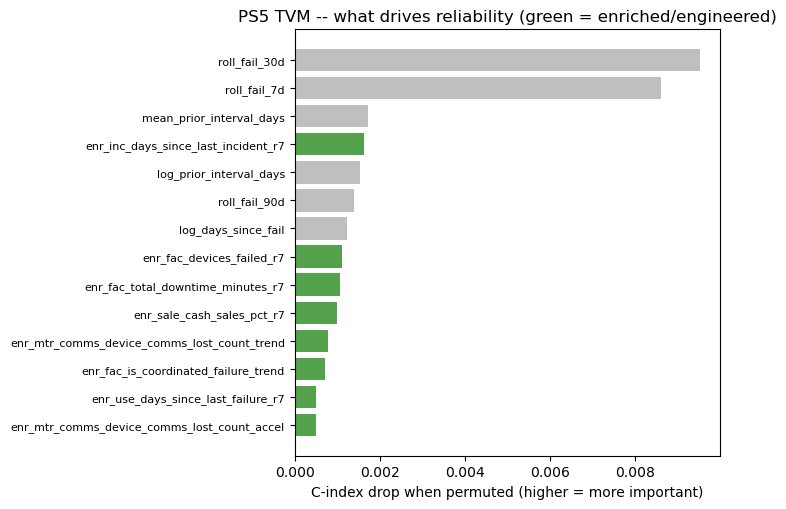

      Integrated Brier Score (lower=better): 0.1850

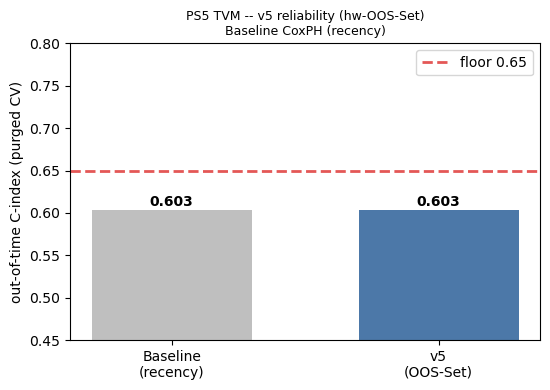

  [event=hw_oos_set] device_failures 132,327 -> 132,308 episodes (505 devices) | filters: NONE APPLIED (columns absent — CONFIRM device_failures schema)

    [device] RUL scored 425 devices | Weibull shape=0.83 scale=13 | median RUL 17d | CRITICAL 43 | overdue 257 -> tvm_device_rul_estimates.csv (+ params)

  [event=hw_oos_set] device_failures 132,327 -> 132,308 episodes (505 devices) | filters: NONE APPLIED (columns absent — CONFIRM device_failures schema)

    [serial] 1,963 components (device_ps5_component) -> tvm_serial_reliability.csv | tiers {'CRITICAL': 1812, 'LOW': 61, 'HIGH': 51, 'MEDIUM': 39}

 GATE -- PS5 RELIABILITY (v5, event=hw-OOS-Set)

...

      Enriched CoxPH (perm-selected)     feats= 70  C-index 0.6800 +/- 0.021

      Enriched WeibullAFT                feats= 70  C-index 0.6690 +/- 0.024

      Enriched Cox + facility frailty    feats= 70  C-index 0.6630 +/- 0.039

      Enriched CoxPH (all)               feats=101  C-index 0.5966 +/- 0.035

      top C-index drivers: enr_rd_reject_rate_pct_trend, eng_log_cumulative_maint_events, enr_rd_rejected_read_count_trend, roll_fail_30d, enr_use_cumulative_maint_events_r7, enr_inc_days_since_last_incident_r7

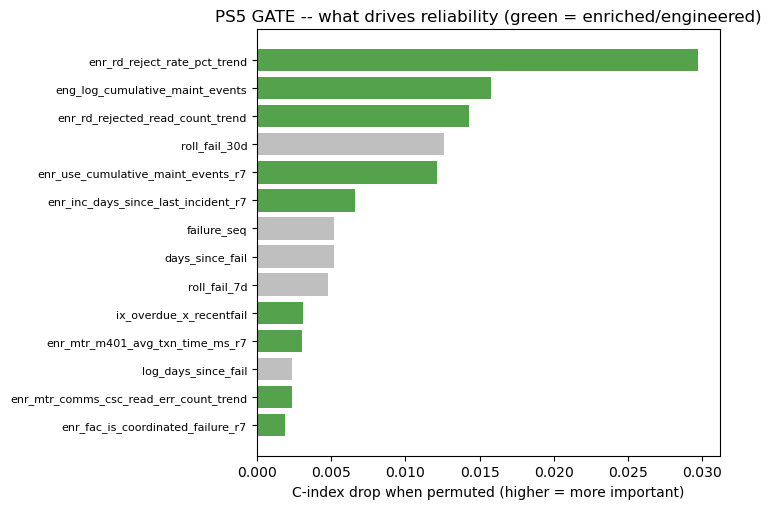

      Integrated Brier Score (lower=better): 0.1506

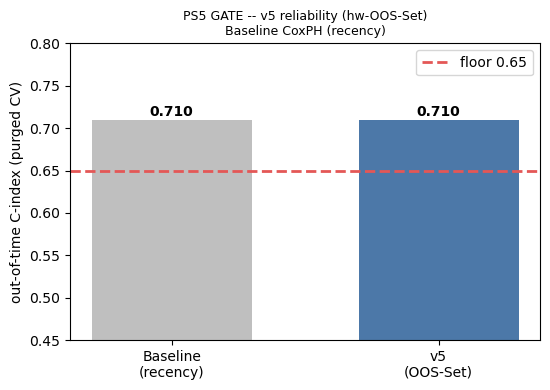

  [event=hw_oos_set] device_failures 22,572 -> 22,572 episodes (944 devices) | filters: NONE APPLIED (columns absent — CONFIRM device_failures schema)

    [device] RUL scored 451 devices | Weibull shape=0.51 scale=160 | median RUL 470d | CRITICAL 46 | overdue 336 -> gates_device_rul_estimates.csv (+ params)

  [event=hw_oos_set] device_failures 22,572 -> 22,572 episodes (944 devices) | filters: NONE APPLIED (columns absent — CONFIRM device_failures schema)

    [serial] 1,236 components (device_ps5_component) -> gates_serial_reliability.csv | tiers {'CRITICAL': 611, 'HIGH': 327, 'MEDIUM': 174, 'LOW': 124}

 VALIDATOR -- PS5 RELIABILITY (v5, event=hw-OOS-Set)

...

      Enriched Cox + facility frailty    feats= 59  C-index 0.6428 +/- 0.006

      Baseline CoxPH (recency)           feats= 13  C-index 0.6299 +/- 0.004

      Enriched Coxnet (L1-selected)      feats= 13  C-index 0.6289 +/- 0.004

      Enriched WeibullAFT                feats= 59  C-index 0.5816 +/- 0.032

      top C-index drivers: roll_fail_7d, eng_log_cumulative_outage_min, failure_seq, eng_failures_per_year, roll_fail_30d, enr_mtr_comms_csc_read_err_count_r7

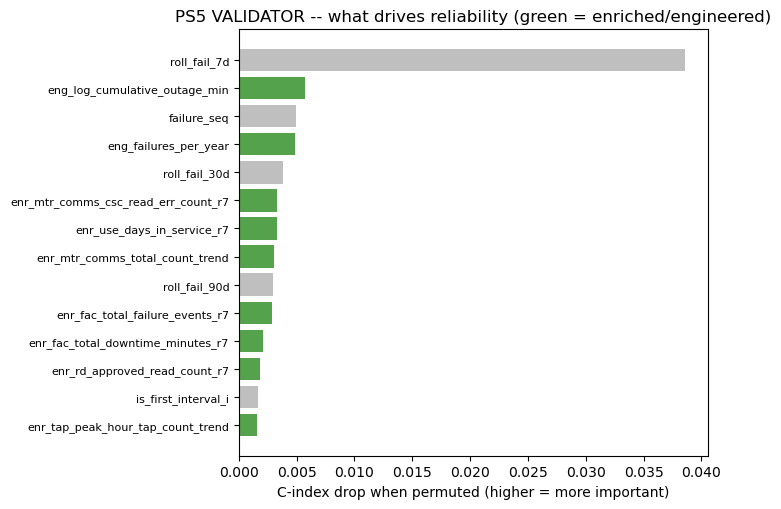

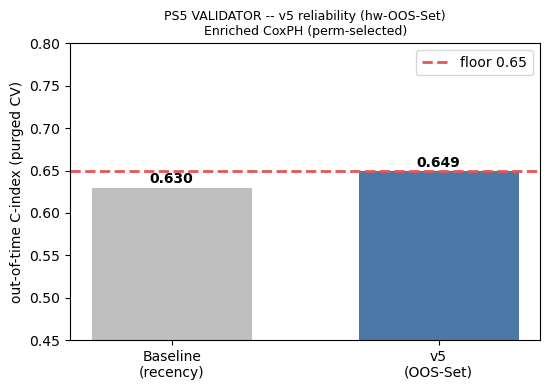

  [event=hw_oos_set] device_failures 582,255 -> 582,255 episodes (1,573 devices) | filters: NONE APPLIED (columns absent — CONFIRM device_failures schema)

    [device] RUL scored 917 devices | Weibull shape=0.95 scale=1 | median RUL 1d | CRITICAL 92 | overdue 856 -> validators_device_rul_estimates.csv (+ params)

  [event=hw_oos_set] device_failures 582,255 -> 582,255 episodes (1,573 devices) | filters: NONE APPLIED (columns absent — CONFIRM device_failures schema)

    [serial] 8,519 components (device_ps5_component) -> validators_serial_reliability.csv | tiers {'LOW': 5737, 'CRITICAL': 2422, 'HIGH': 181, 'MEDIUM': 179}

 PS5 v5 RELIABILITY SUMMARY

 TVM        baseline(all-yrs) 0.6137 | window=telemetry_era baseline 0.6034 -> reworked 0.6034 (lift +0.0) [Baseline CoxPH (recency)] below floor

 GATE       baseline(all-yrs) 0.6544 | window=telemetry_era baseline 0.7095 -> reworked 0.7095 (lift +0.0) [Baseline CoxPH (recency)] PASS

 VALIDATOR  baseline(all-yrs) 0.6212 | window=telemetry_era baseline 0.6299 -> reworked 0.6493 (lift +0.0194) [Enriched CoxPH (perm-selected)] below floor


[manifest] device feeds=3 serial feeds=3 -> ps5_rds_load_manifest.json (event=2026-07-23.v1)

In [4]:
SMOKE_TEST = False          # LIVE S3/Spark run by default. Set True for the offline synthetic dry-run.

# ---- event definition (unchanged from v5) ----
# CONFIG["HW_OOS_SET"]["require_chargeable"] = False   # any hardware OOS (True = only the chargeable SLA subset)
CONFIG["FIT_TREE_MODELS"] = False
# ---- v5.1 device/serial scoring ----
# CONFIG["EMIT_DEVICE_SERIAL"] = True                  # score + persist device- and serial-grain RUL
# CONFIG["RUL_CAP_DAYS"]       = 3650.0                # display cap (guards degenerate Weibull scale)
# CONFIG["SERIAL_SOURCE"]      = "auto"                # gold.device_ps5_component if present, else hw_config_current

results = main(synthetic=SMOKE_TEST)

## Outputs (per type under `PS5_reliability_v5_outputs/{tvm,gates,validators}/`)
- **gate/CV:** `<type>_cindex_leaderboard_v5.csv`, `<type>_enrich_coverage.csv`, `<type>_permutation_importance.csv/.png`,
  `<type>_cindex_lift.png`, `<type>_reliability_summary.json` (with `event_definition` + `event_def_version`).
- **v5.1 device:** `<type>_device_rul_estimates.csv` (RUL + recency + risk), `<type>_device_survival_params.json`
  (slim servable params), `<type>_device_state.parquet` (feature vectors the Lambda scores).
- **v5.1 serial:** `<type>_serial_reliability.csv`, `<type>_serial_params.json`.
- **top level:** `ps5_rds_load_manifest.json`.

## Next in the chain (built + delivered alongside this notebook)
1. **Upload** params + state + feeds to S3 (`s3://…/chicago/ps5/{params,state}/…`).
2. **RDS:** apply `06_phase1d_ps5_oos_set_reliability.sql` (additive), then `ps5_rds_writer.py` loads the day-0 feeds.
3. **Lambda:** deploy `ps5_daily_scorer.py` — daily, params-only, upserts per-device + per-serial RUL to RDS.
4. **Dashboard:** the PS5 device/serial subtabs read the `/ps5/reliability` route over the new RDS views.